Noise: 600.0
CSV guardado en: csv_generats\simulated_clusters_1.csv
CSV guardado en: csv_generats\simulated_clusters_2.csv
CSV guardado en: csv_generats\simulated_clusters_3.csv
CSV guardado en: csv_generats\simulated_clusters_4.csv
CSV guardado en: csv_generats\simulated_clusters_5.csv
CSV guardado en: csv_generats\simulated_clusters_6.csv
CSV guardado en: csv_generats\simulated_clusters_7.csv
CSV guardado en: csv_generats\simulated_clusters_8.csv
CSV guardado en: csv_generats\simulated_clusters_9.csv
CSV guardado en: csv_generats\simulated_clusters_10.csv
CSV guardado en: csv_generats\simulated_clusters_11.csv
CSV guardado en: csv_generats\simulated_clusters_12.csv
CSV guardado en: csv_generats\simulated_clusters_13.csv
CSV guardado en: csv_generats\simulated_clusters_14.csv
CSV guardado en: csv_generats\simulated_clusters_15.csv
CSV guardado en: csv_generats\simulated_clusters_16.csv
CSV guardado en: csv_generats\simulated_clusters_17.csv
CSV guardado en: csv_generats\simulated_clus

C:\Users\bertg\AppData\Local\Temp\ipykernel_44160\1809874890.py:87: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10, 10))


CSV guardado en: csv_generats\simulated_clusters_21.csv
CSV guardado en: csv_generats\simulated_clusters_22.csv
CSV guardado en: csv_generats\simulated_clusters_23.csv
CSV guardado en: csv_generats\simulated_clusters_24.csv
CSV guardado en: csv_generats\simulated_clusters_25.csv
CSV guardado en: csv_generats\simulated_clusters_26.csv
CSV guardado en: csv_generats\simulated_clusters_27.csv
CSV guardado en: csv_generats\simulated_clusters_28.csv
CSV guardado en: csv_generats\simulated_clusters_29.csv
CSV guardado en: csv_generats\simulated_clusters_30.csv
CSV guardado en: csv_generats\simulated_clusters_31.csv
CSV guardado en: csv_generats\simulated_clusters_32.csv
CSV guardado en: csv_generats\simulated_clusters_33.csv
CSV guardado en: csv_generats\simulated_clusters_34.csv
CSV guardado en: csv_generats\simulated_clusters_35.csv
CSV guardado en: csv_generats\simulated_clusters_36.csv
CSV guardado en: csv_generats\simulated_clusters_37.csv
CSV guardado en: csv_generats\simulated_clusters

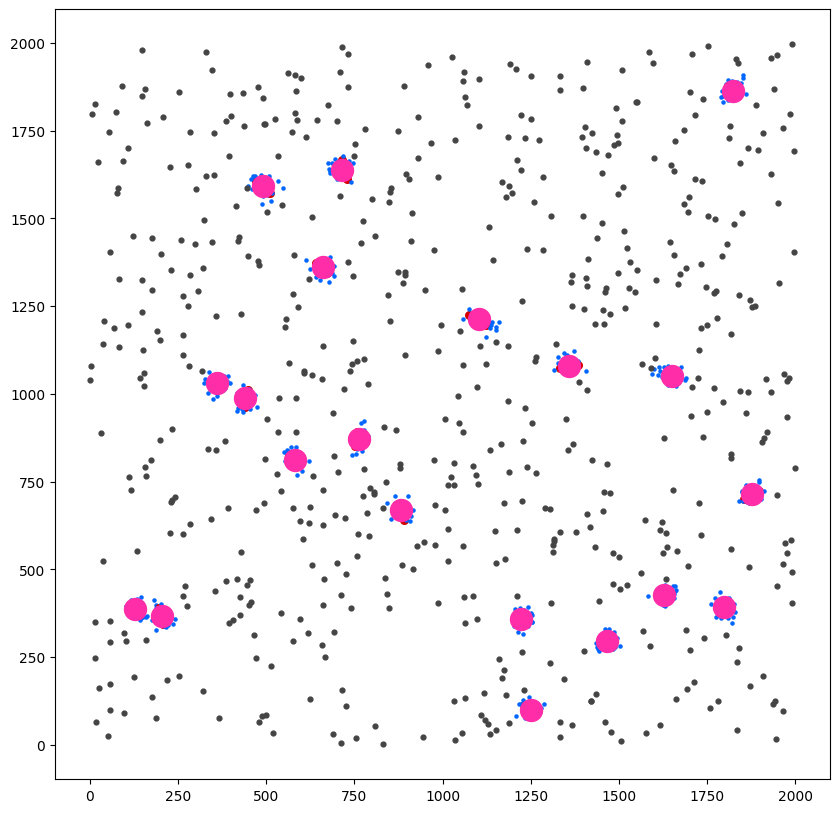

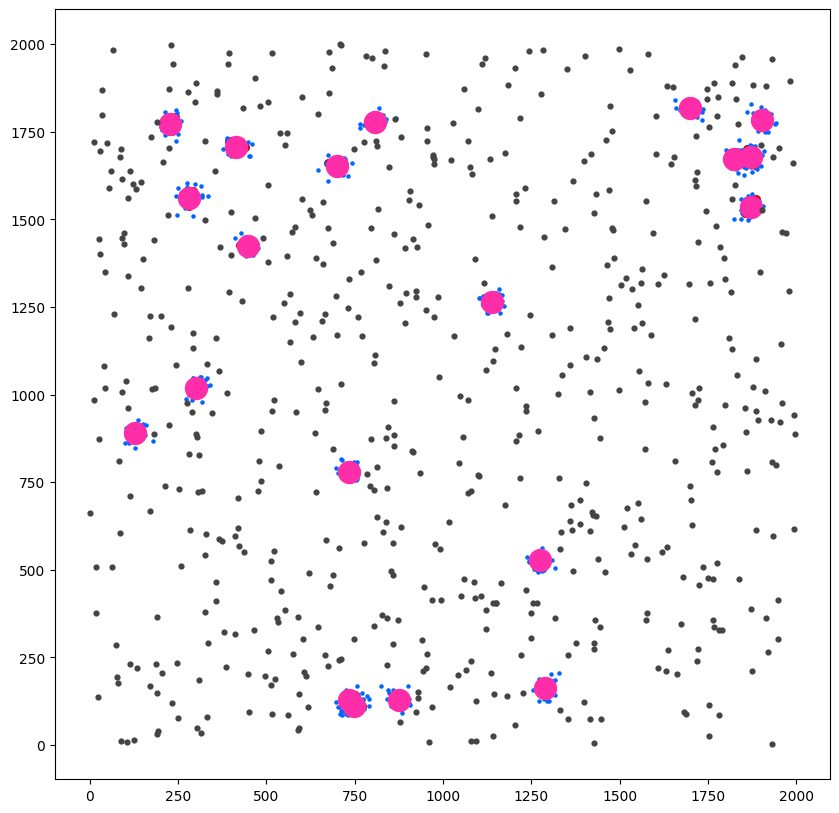

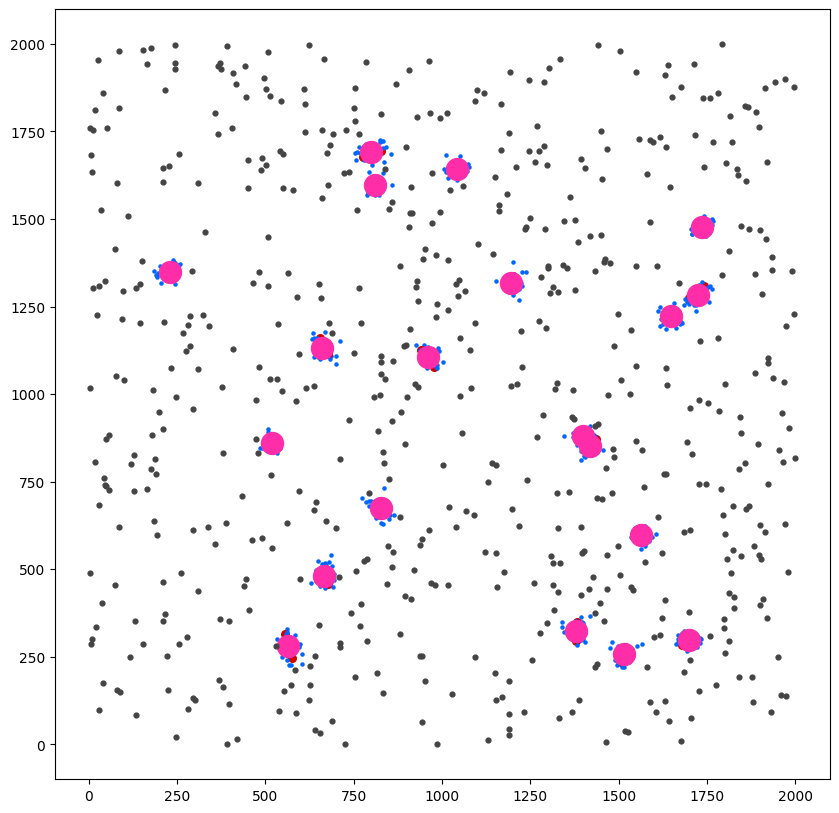

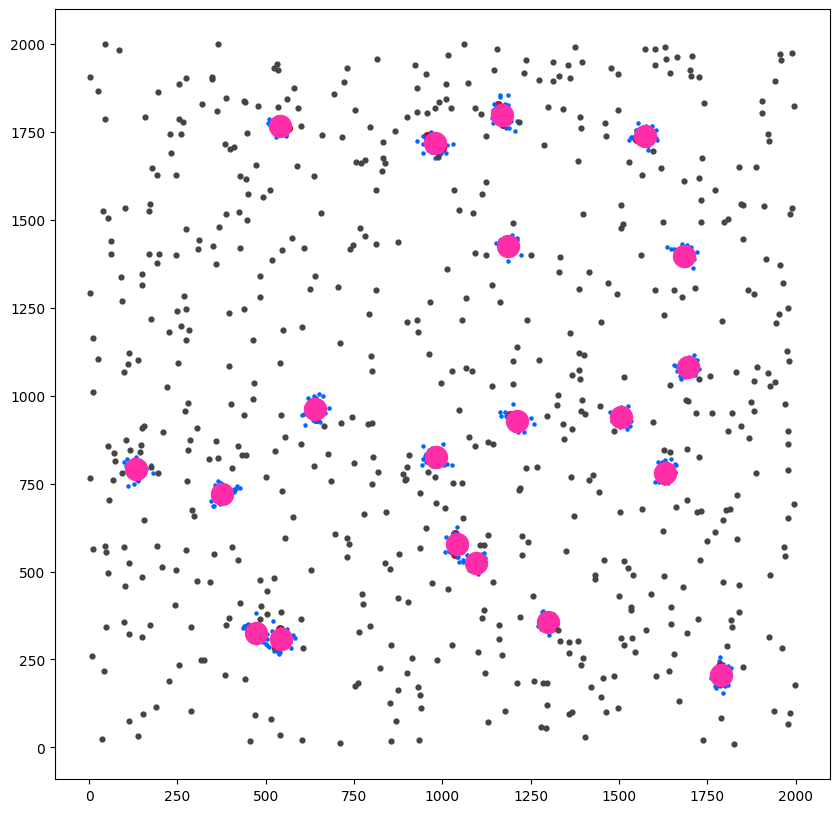

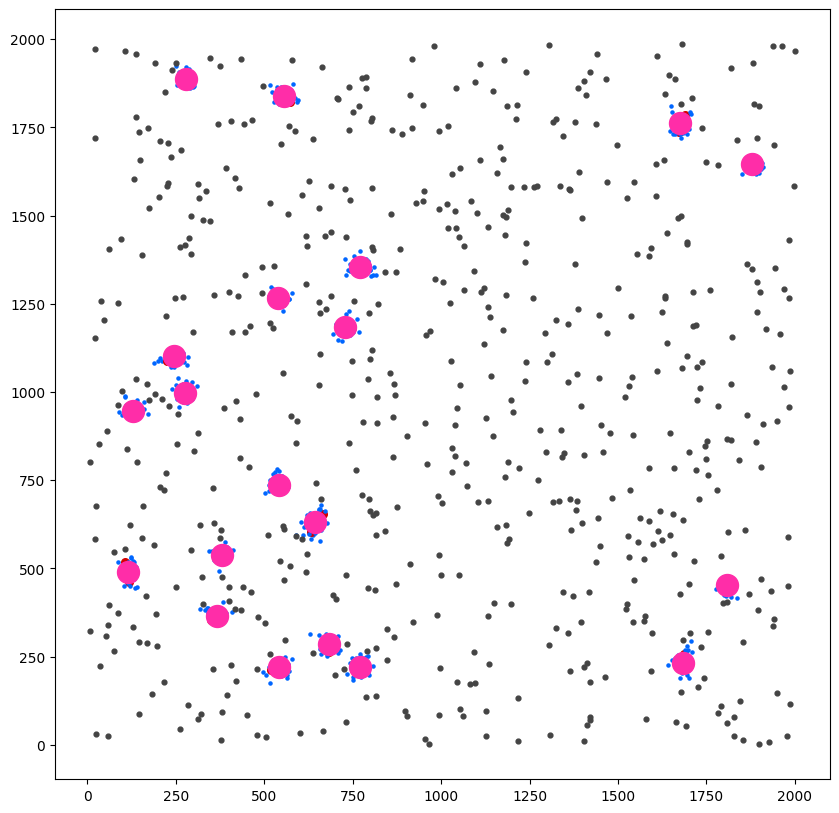

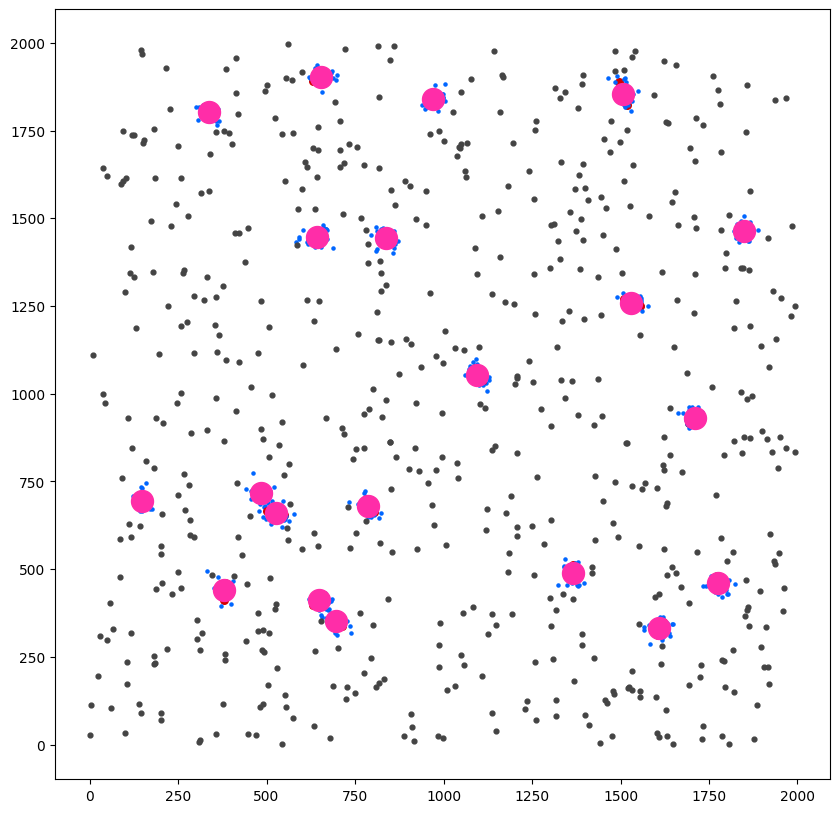

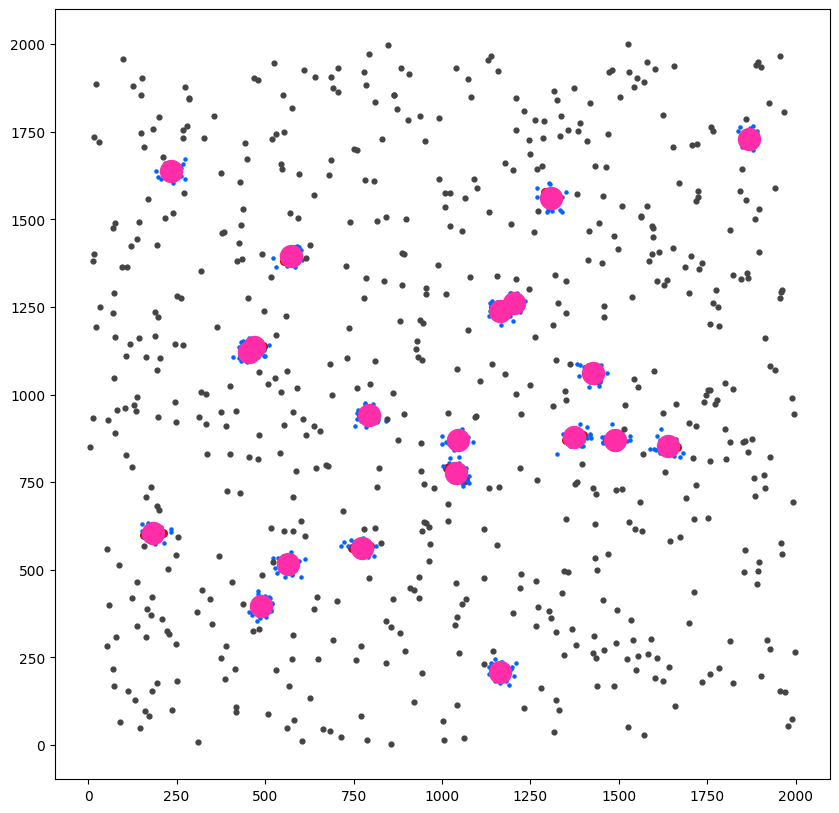

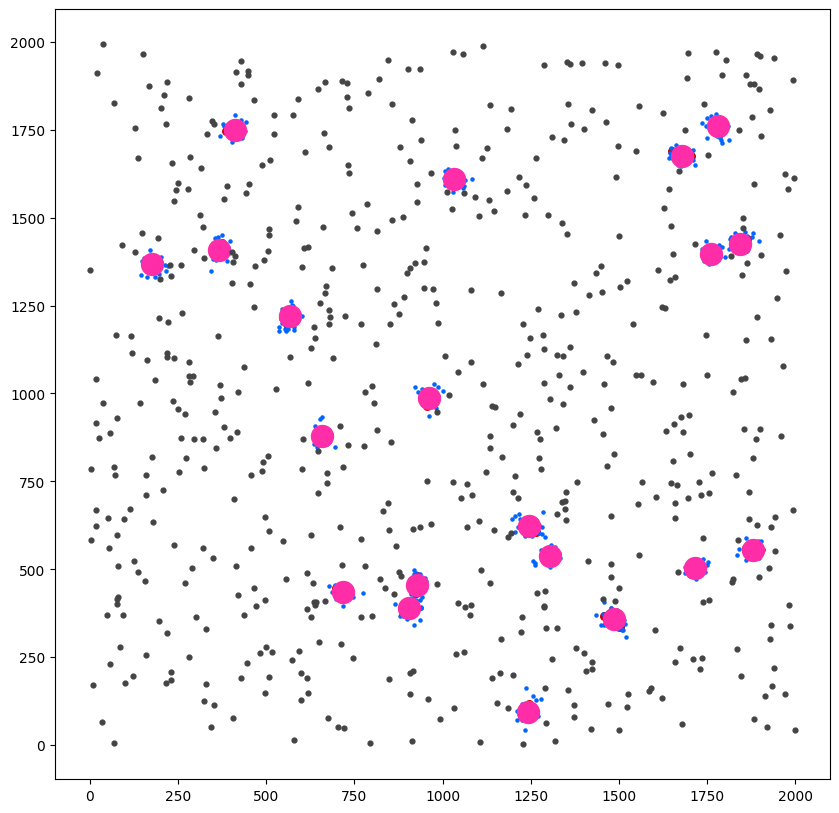

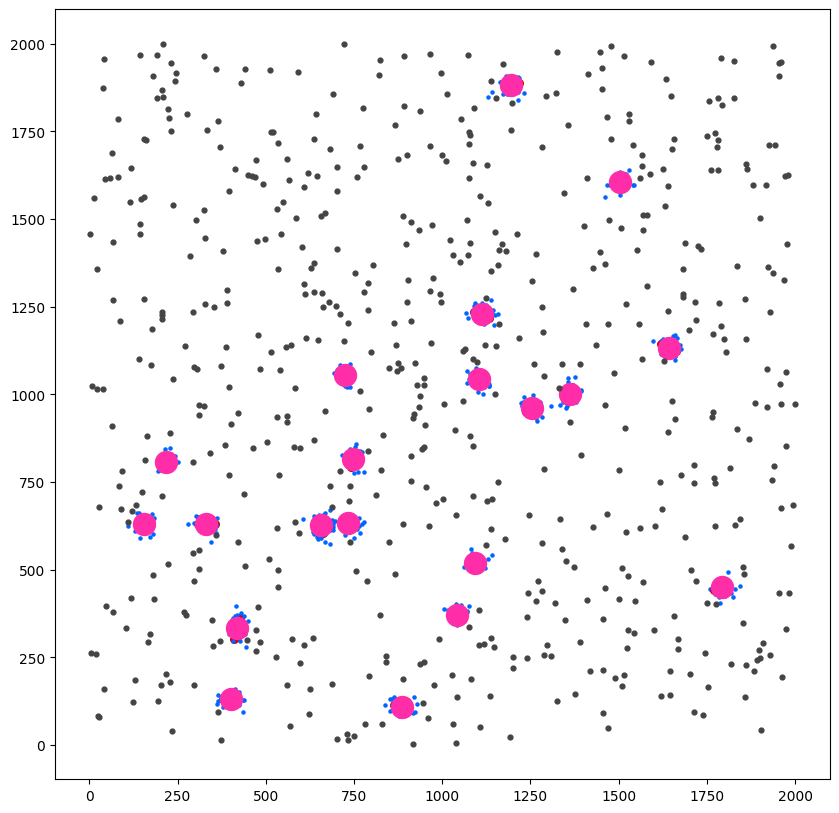

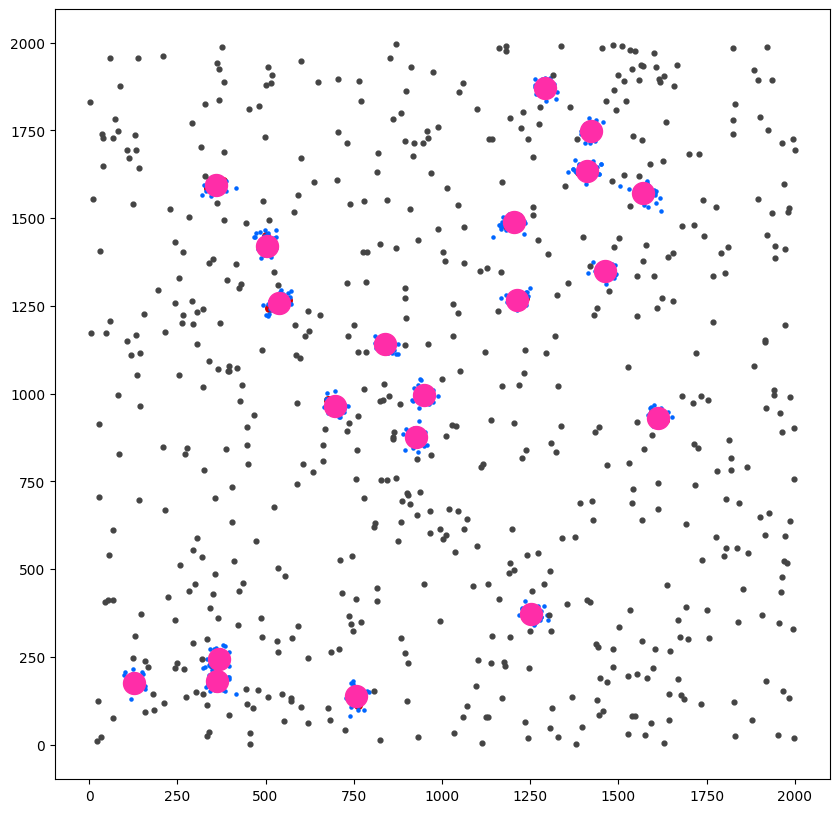

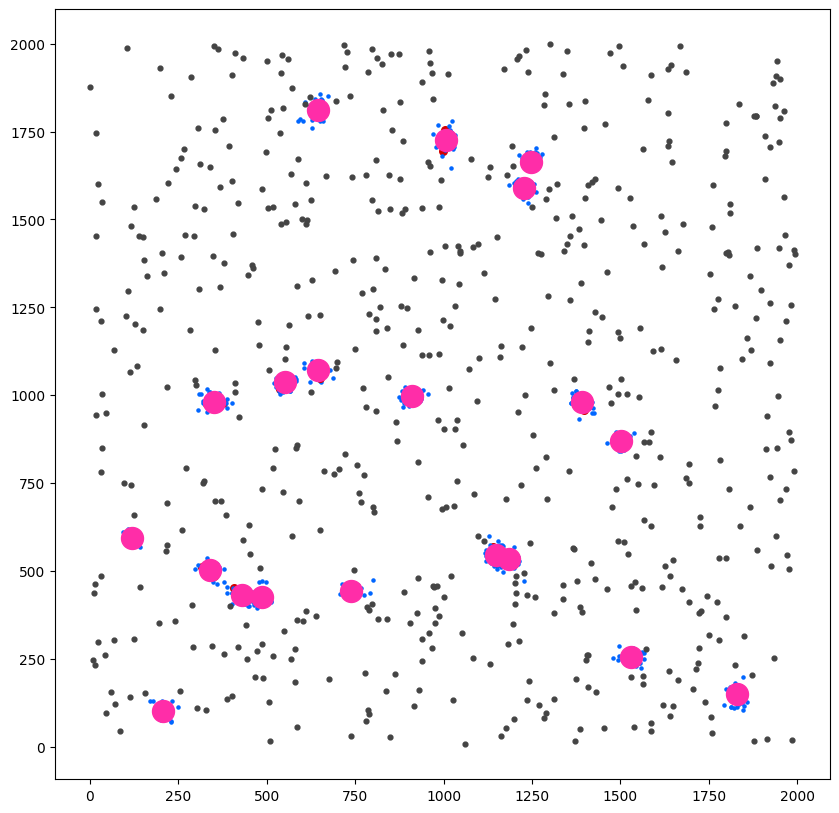

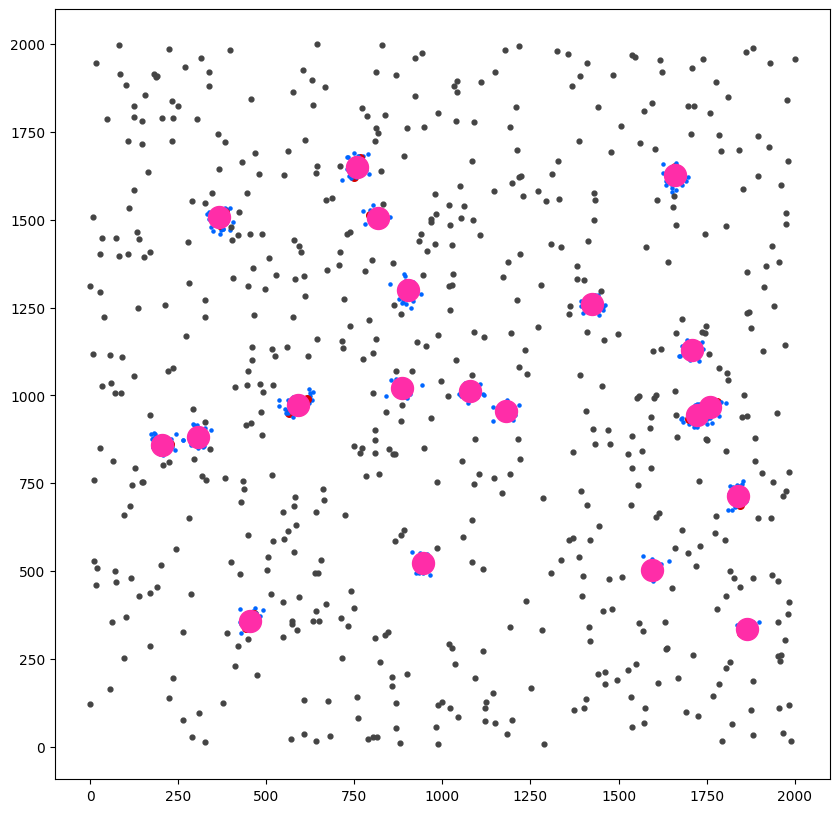

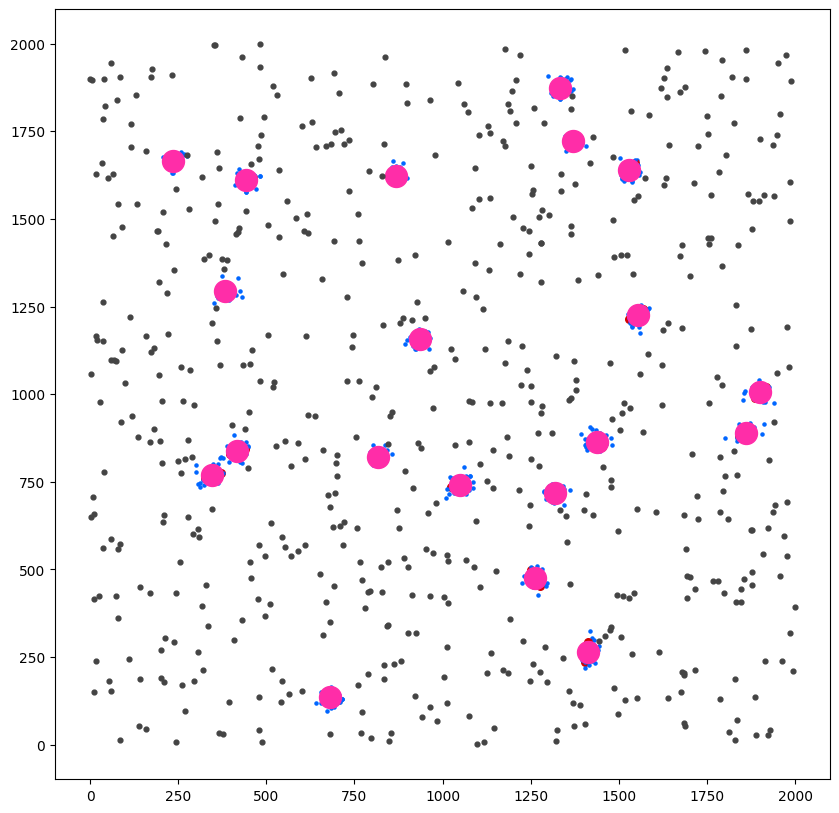

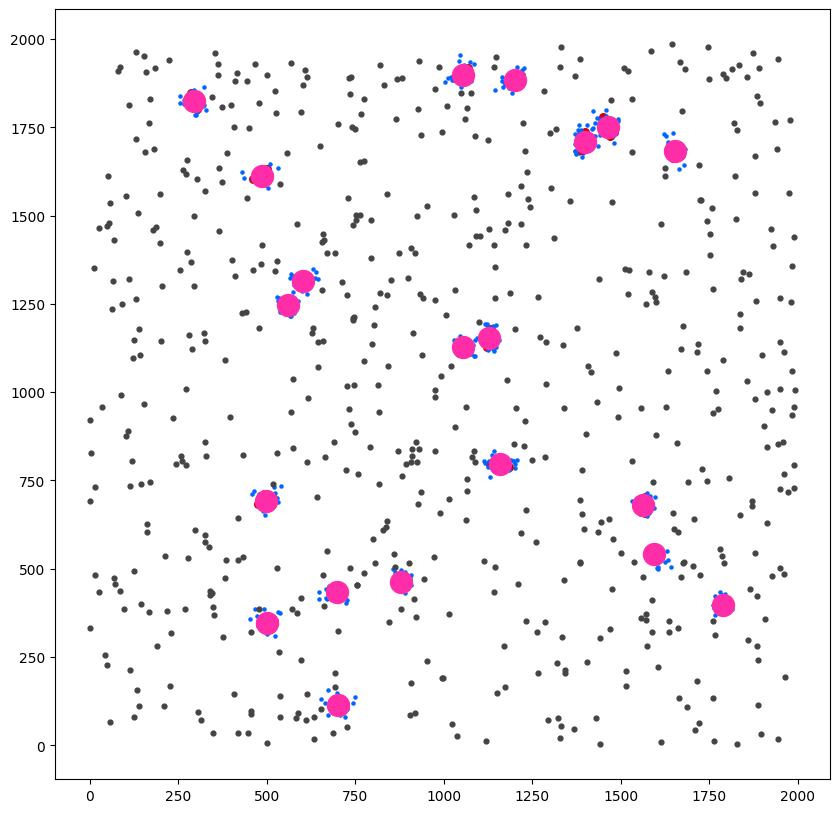

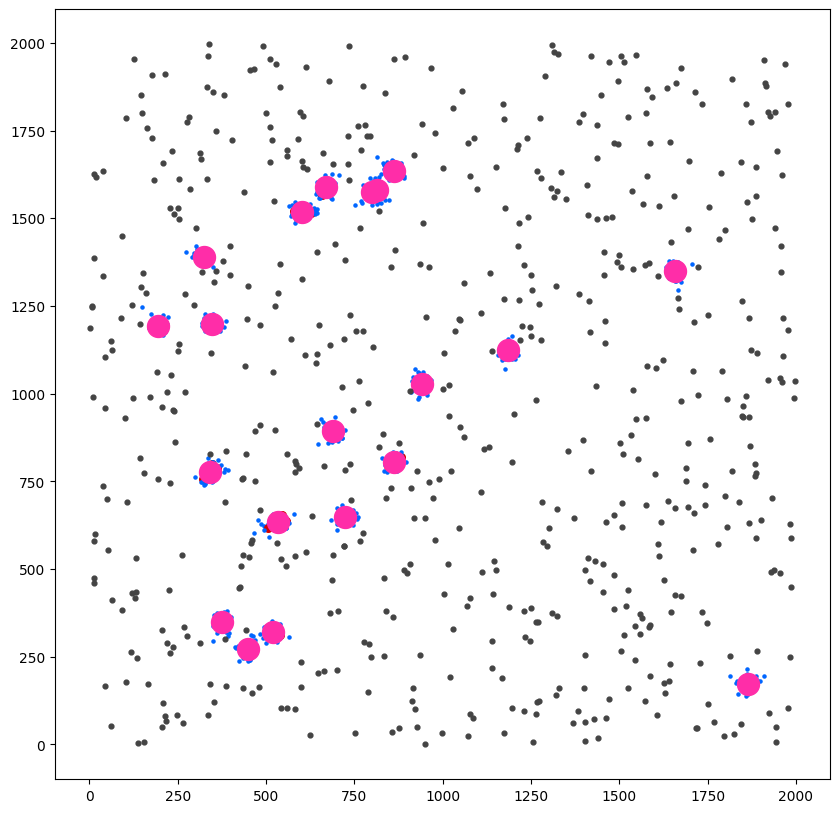

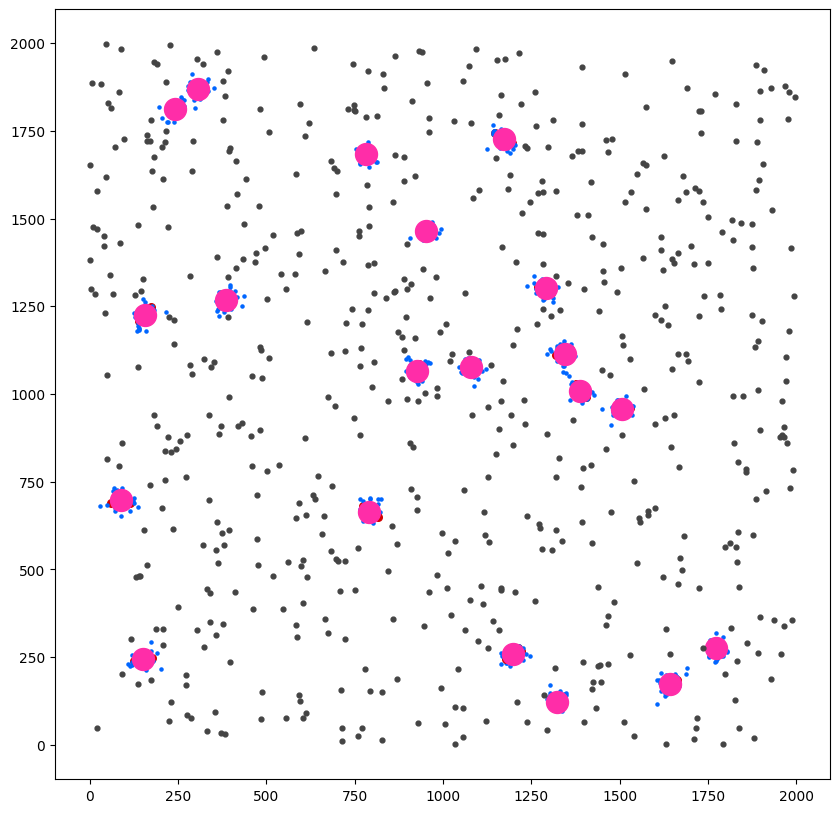

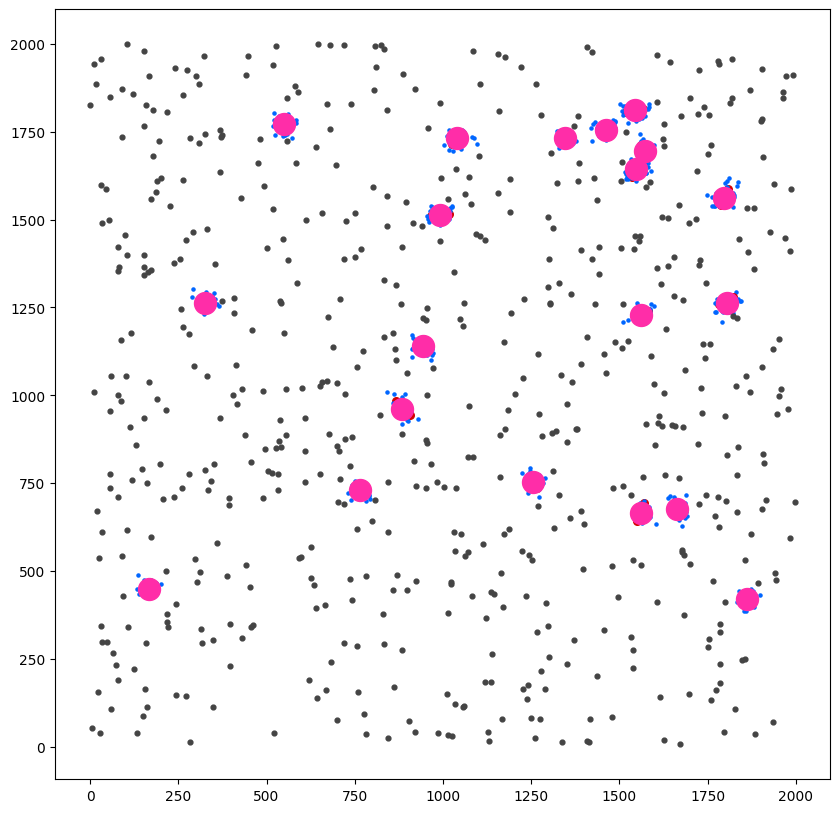

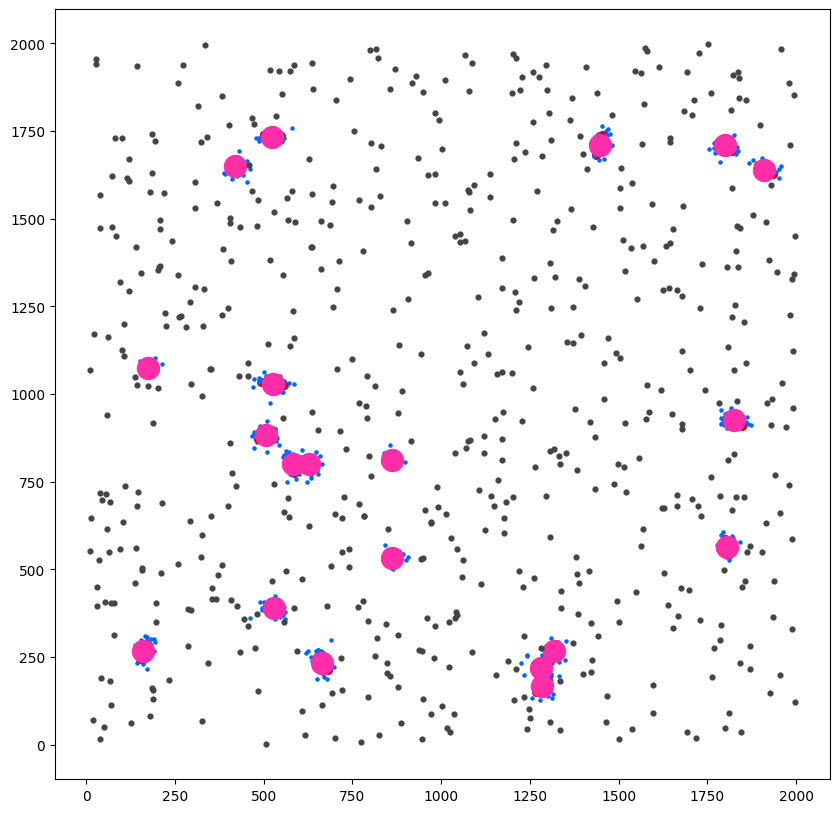

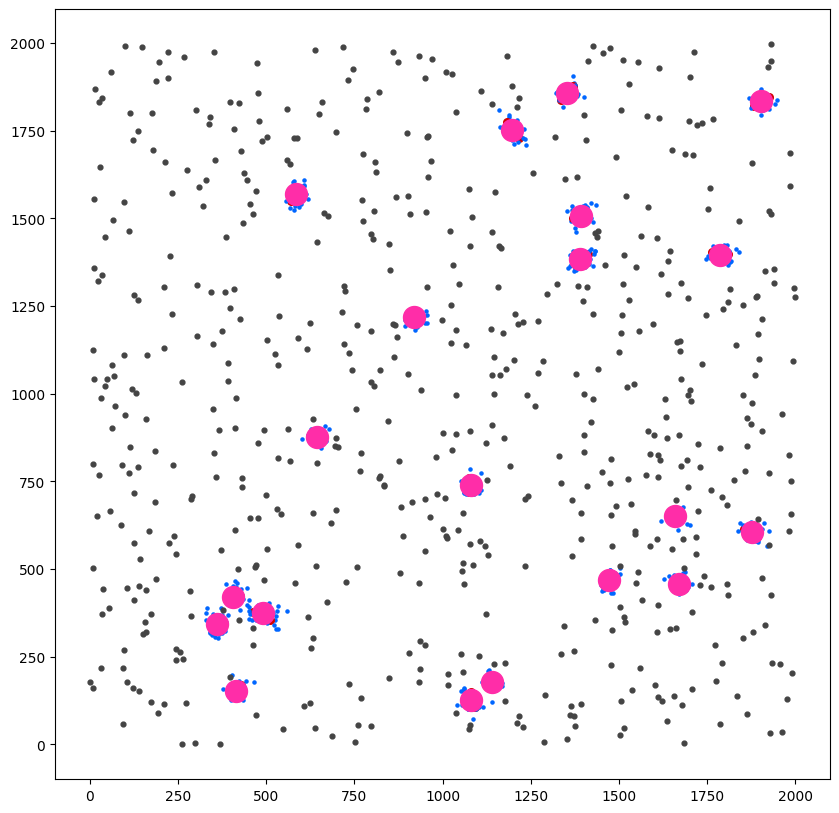

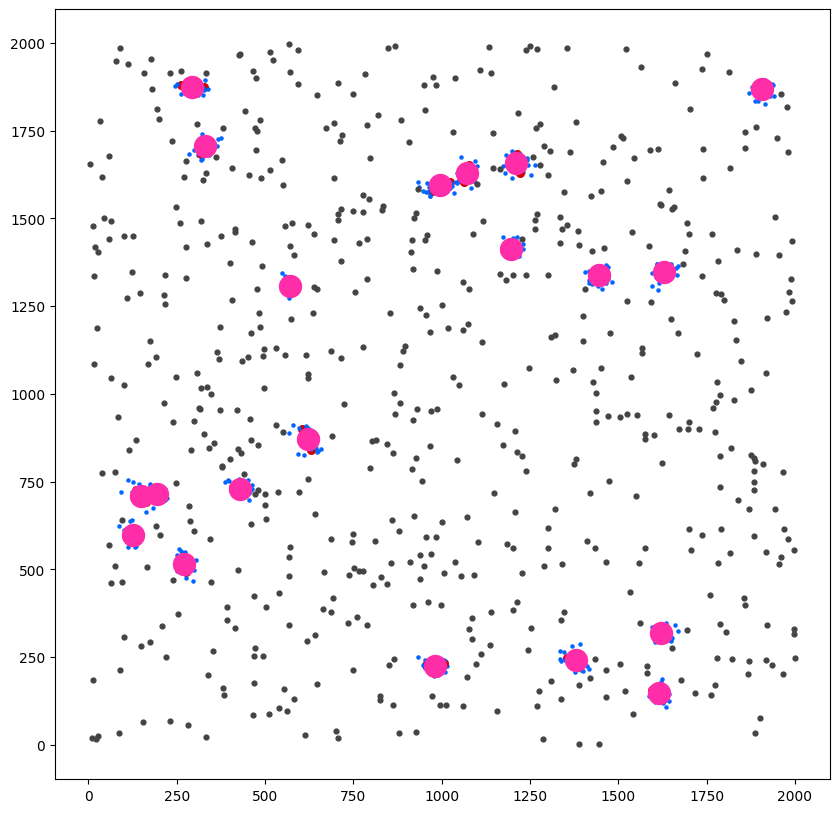

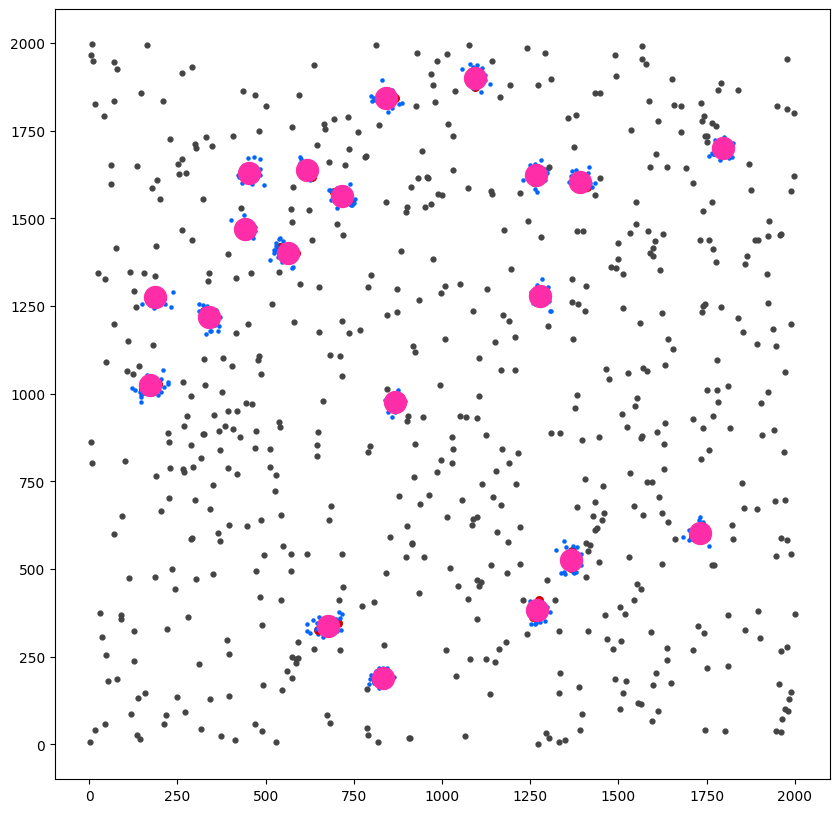

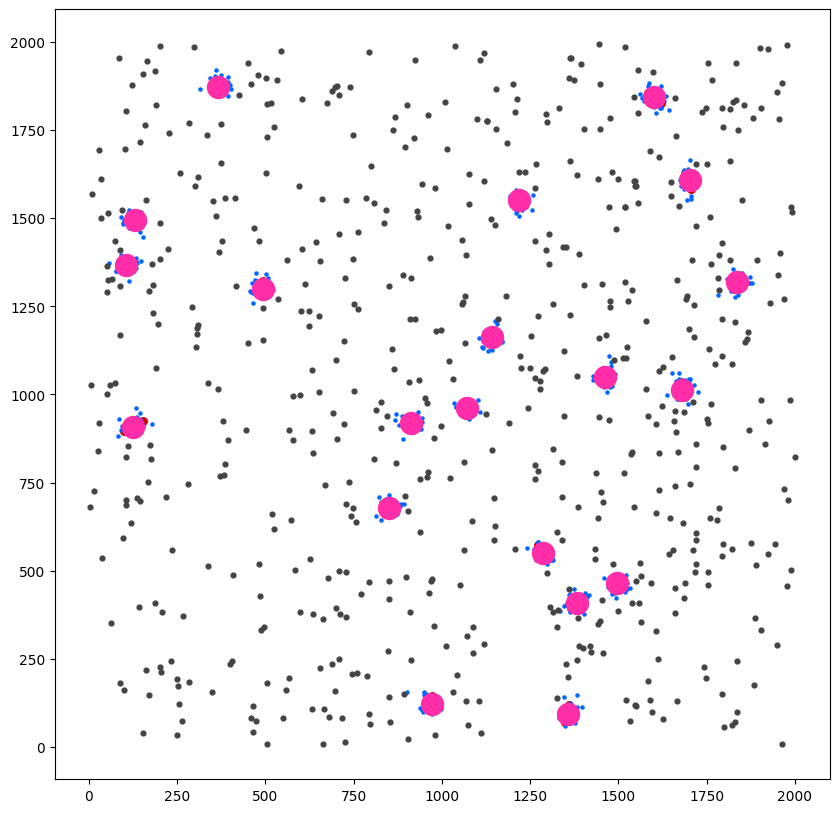

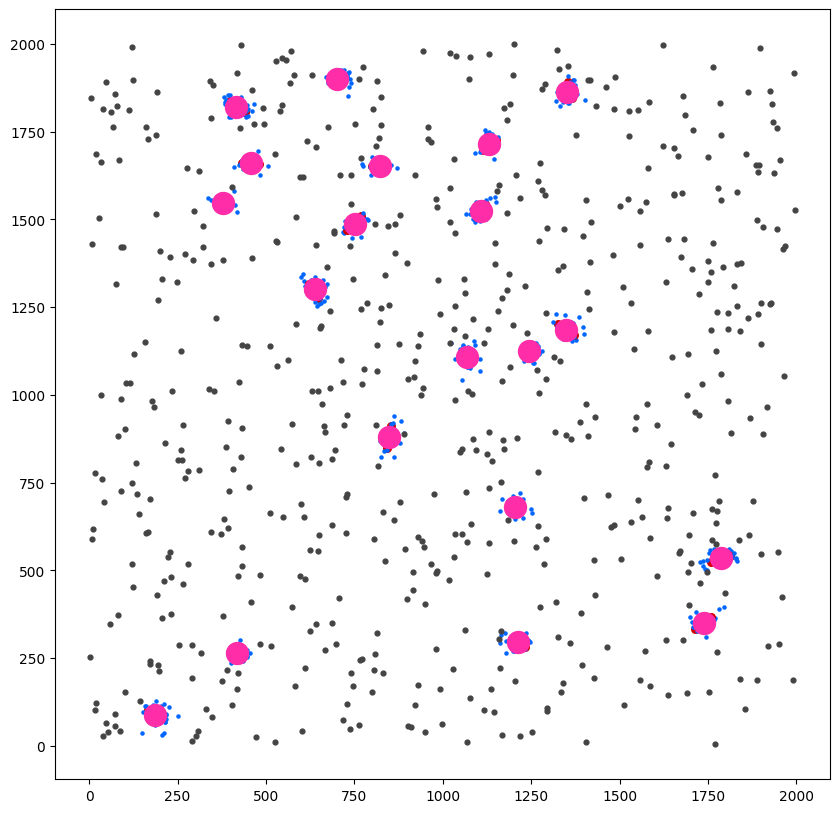

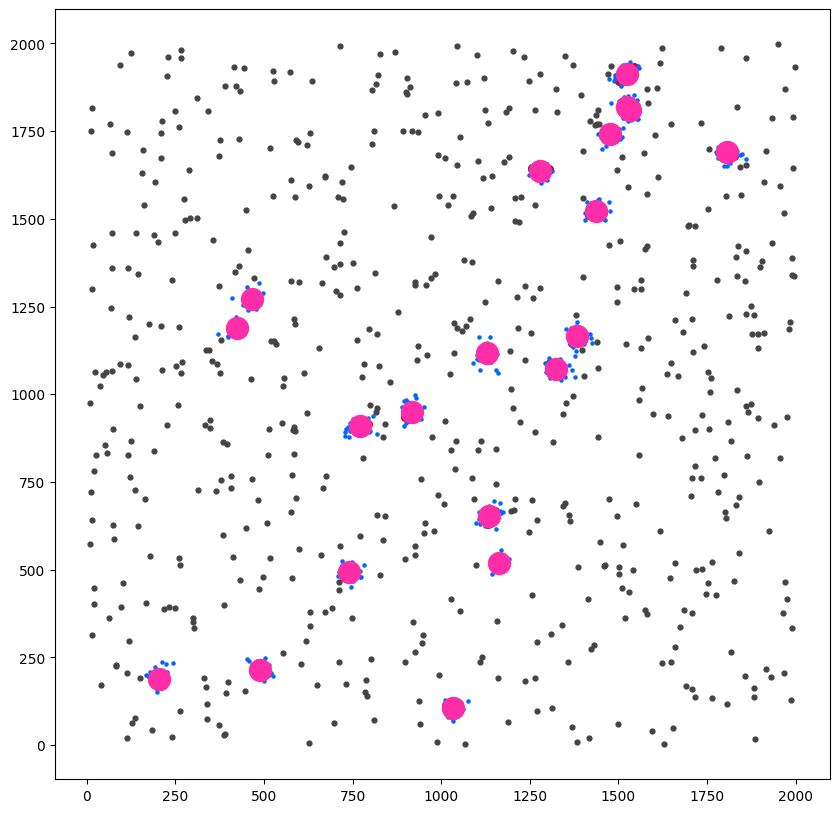

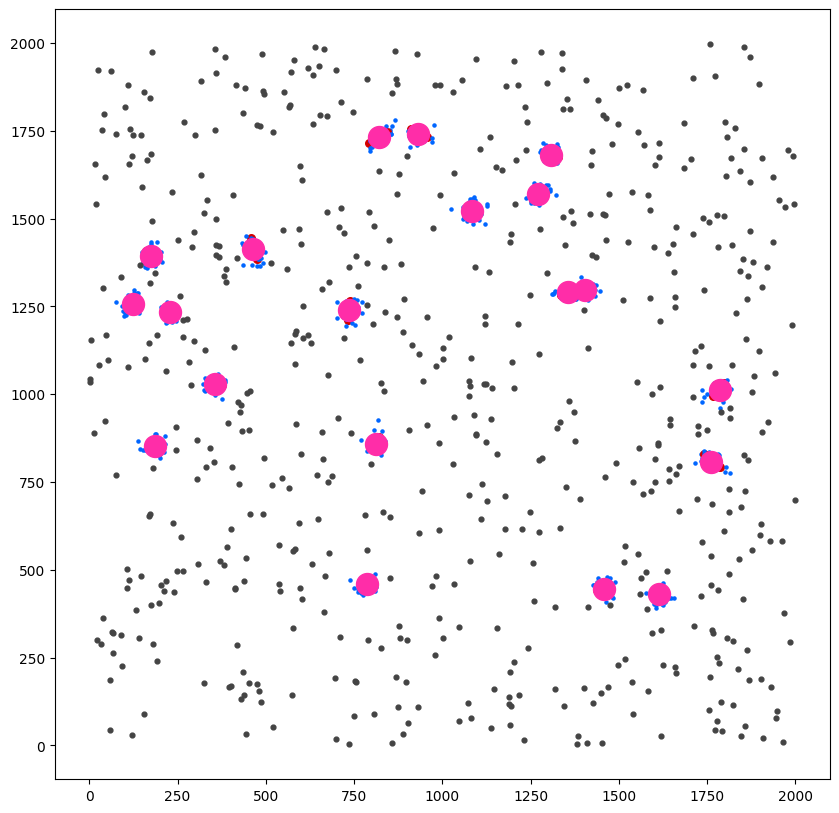

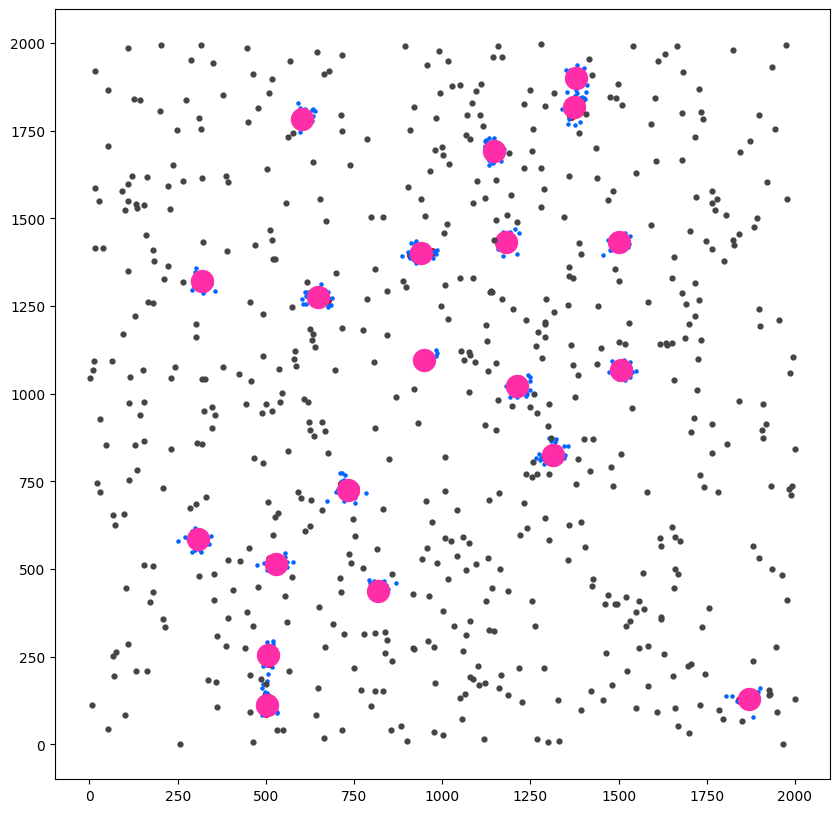

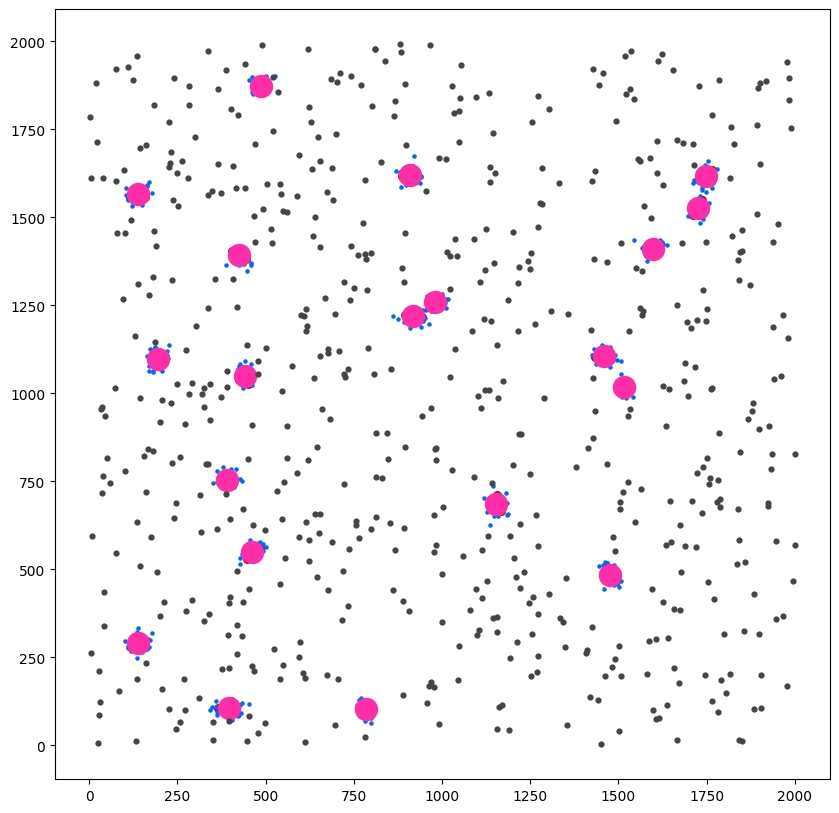

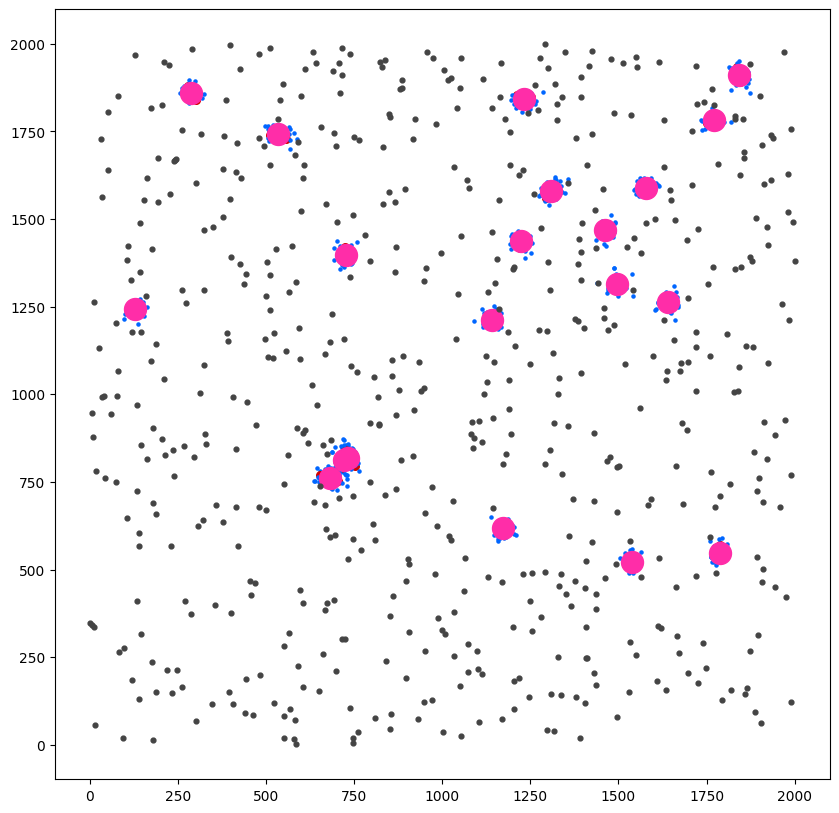

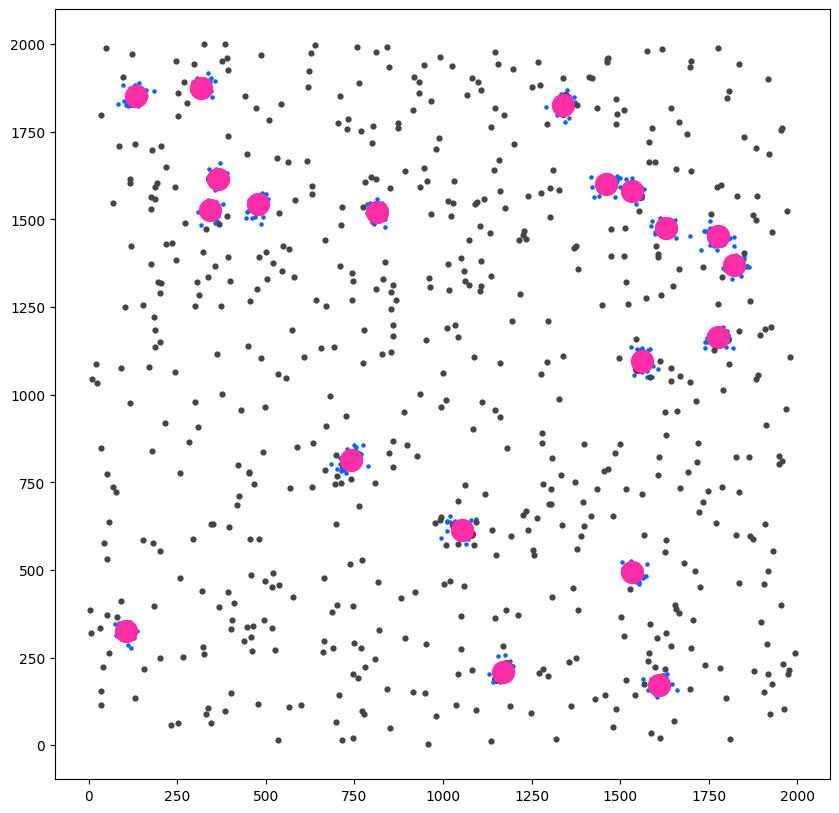

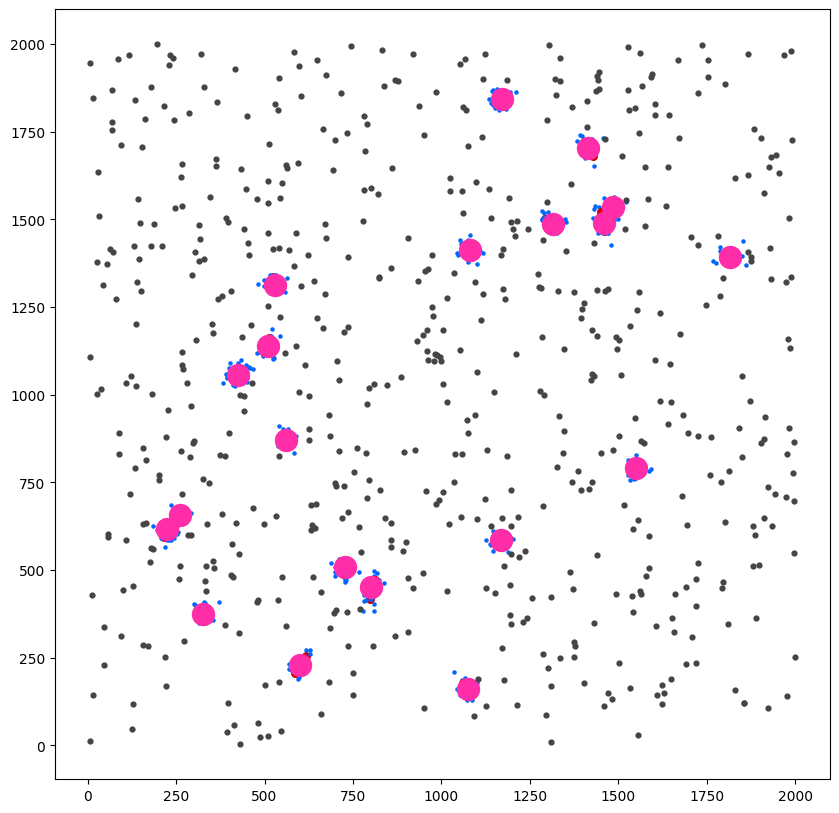

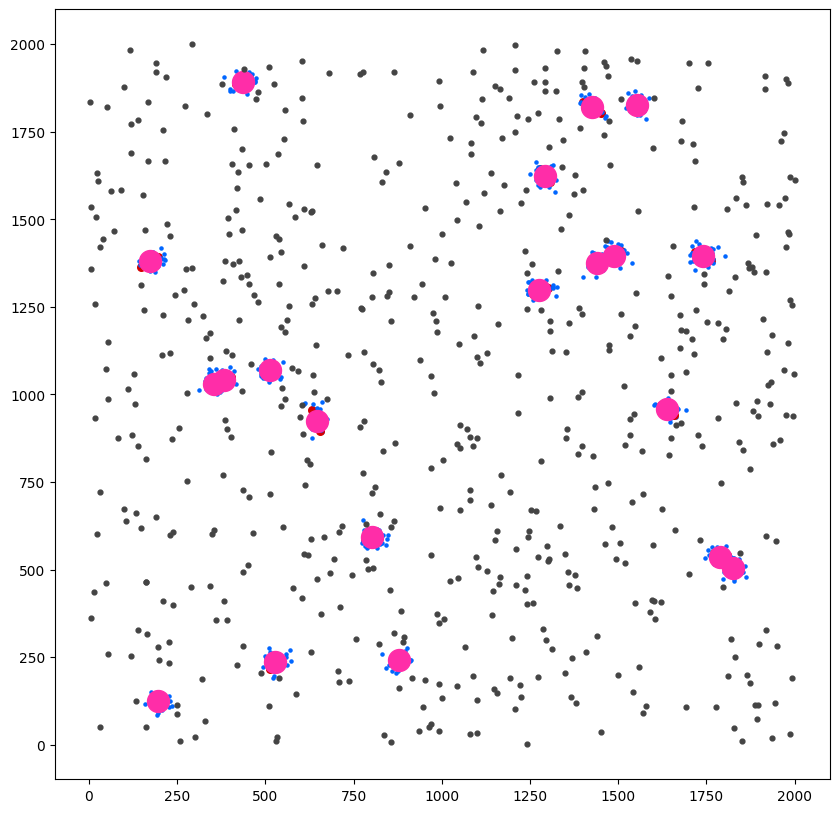

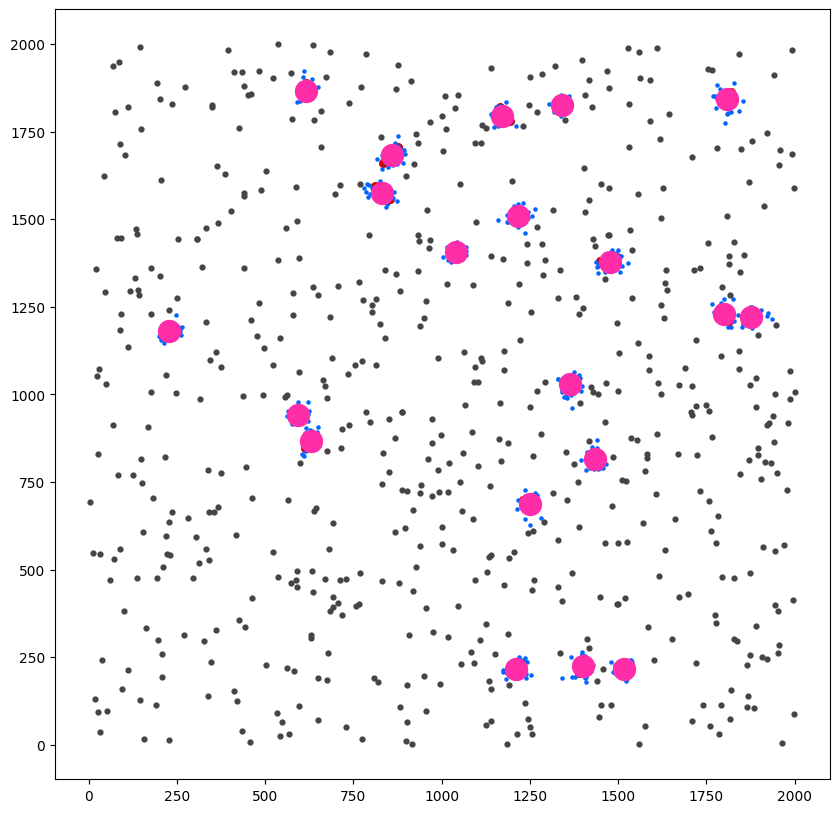

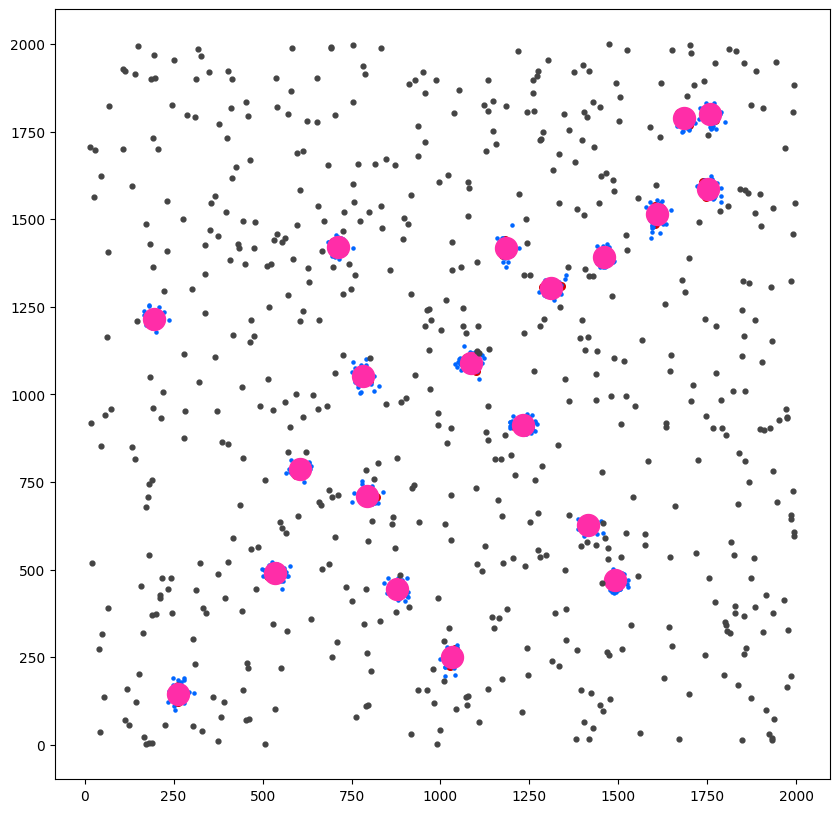

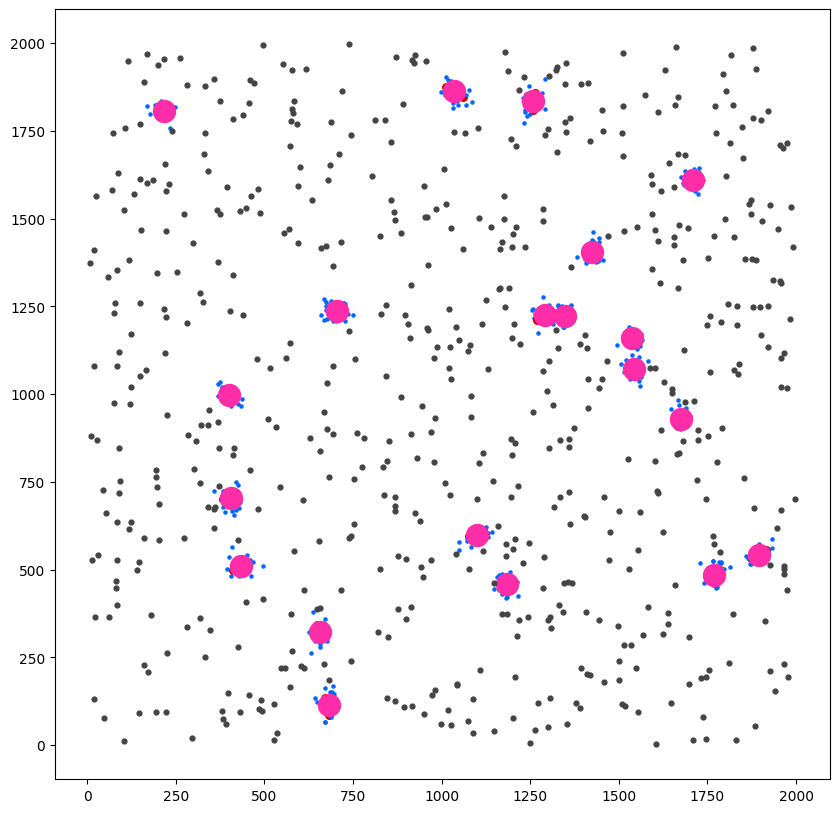

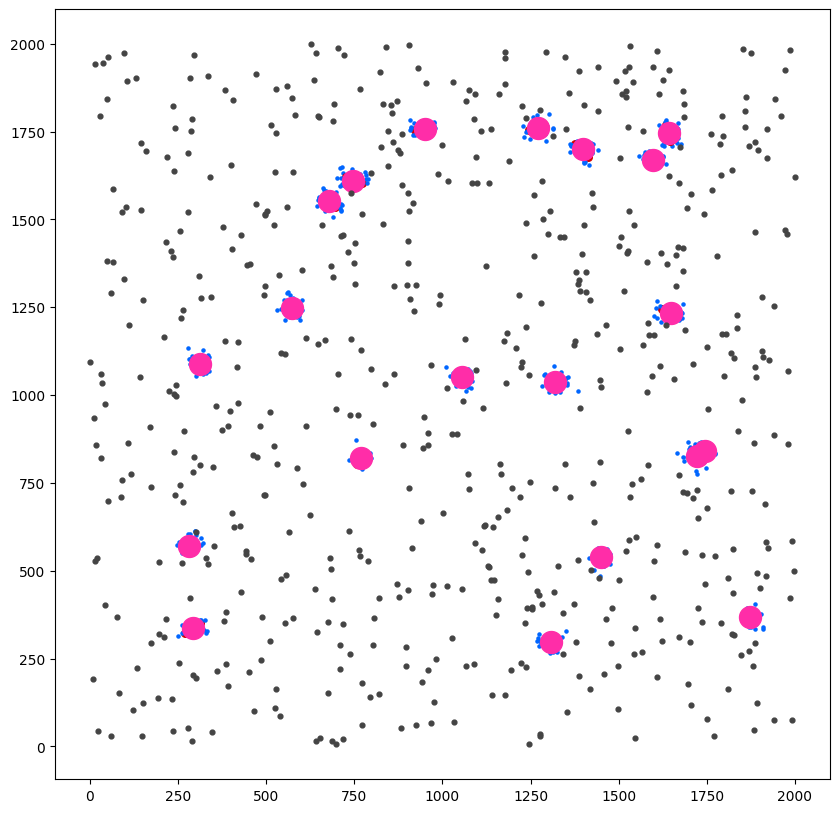

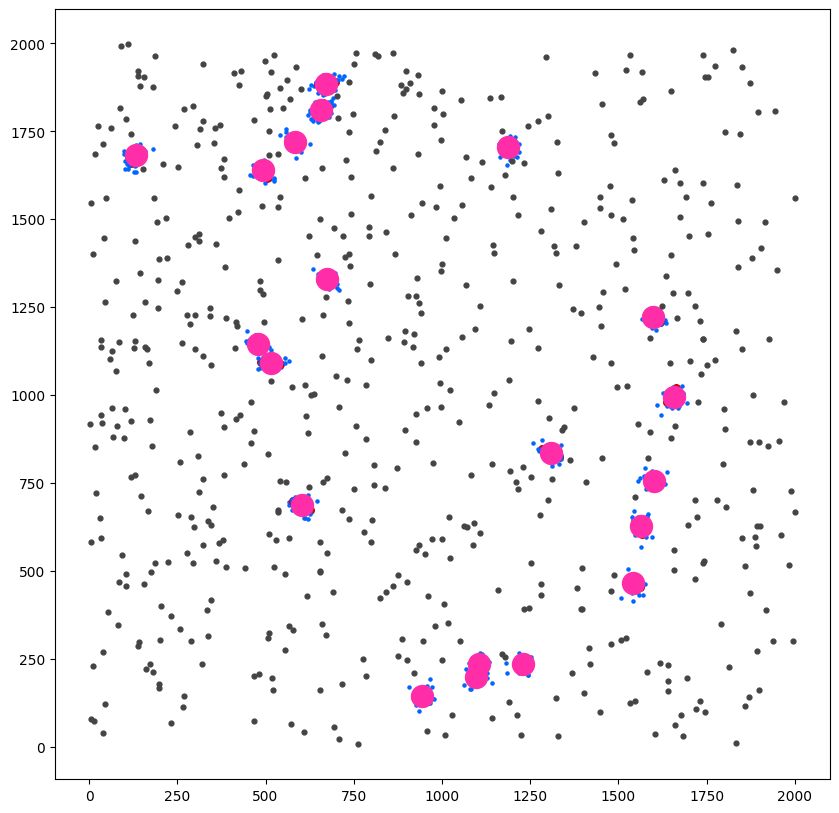

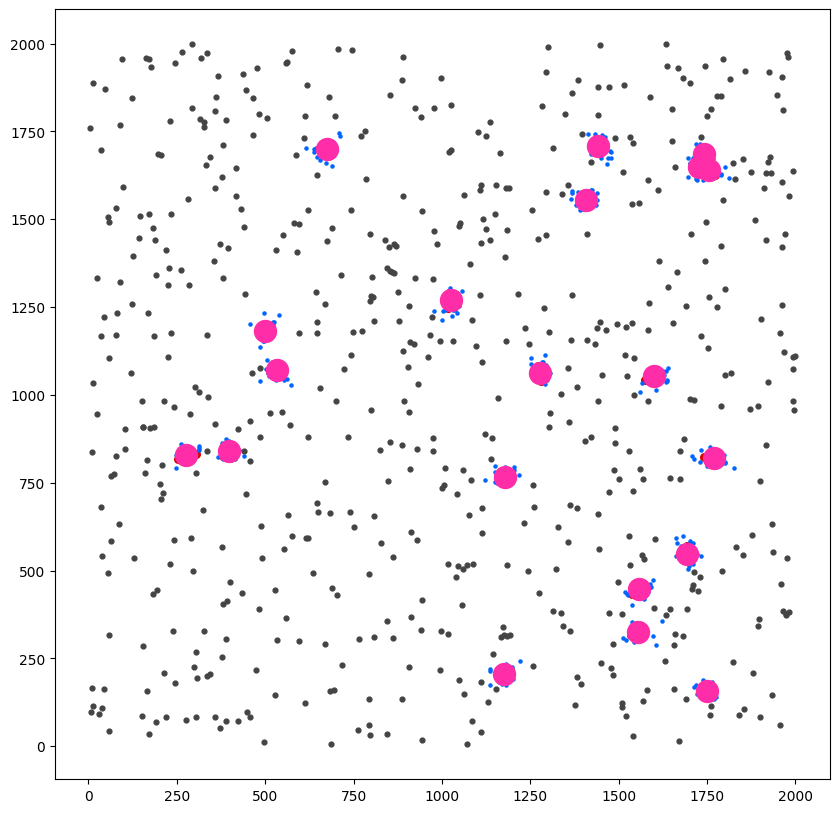

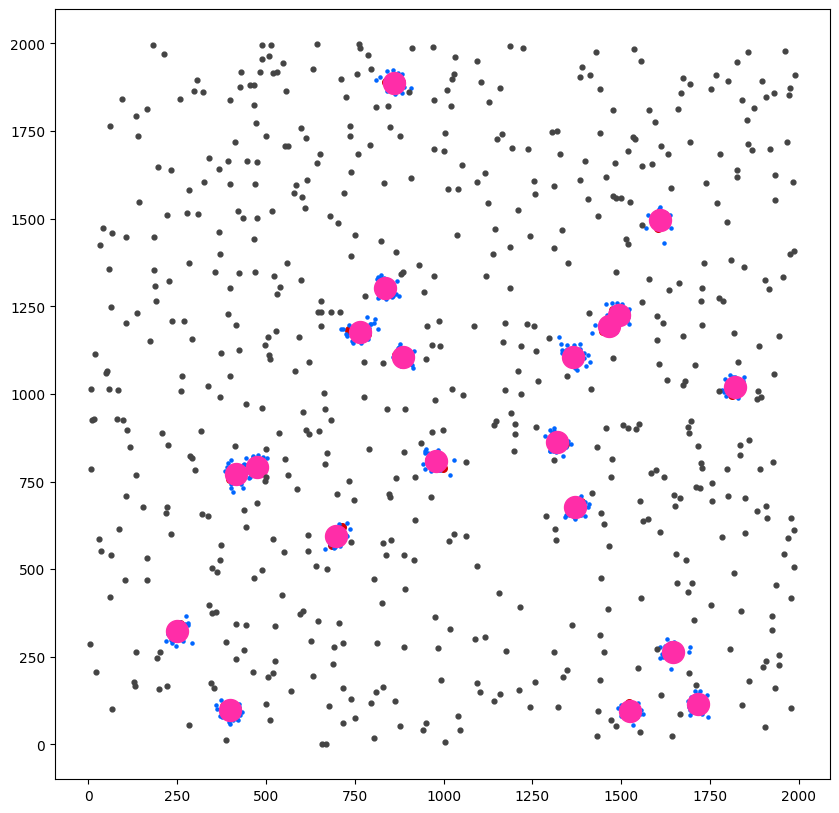

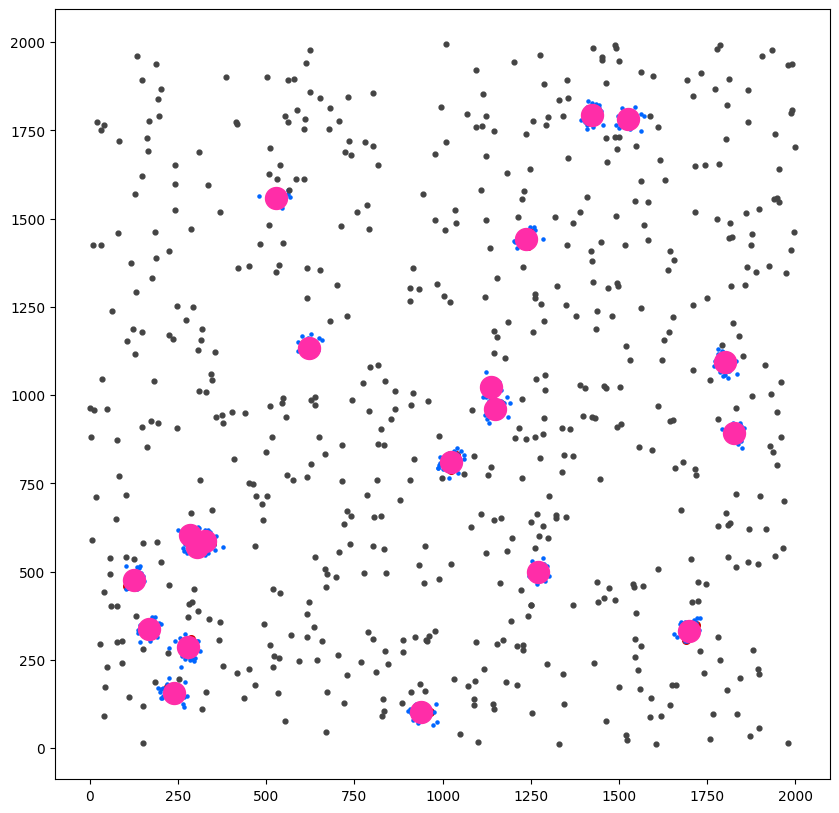

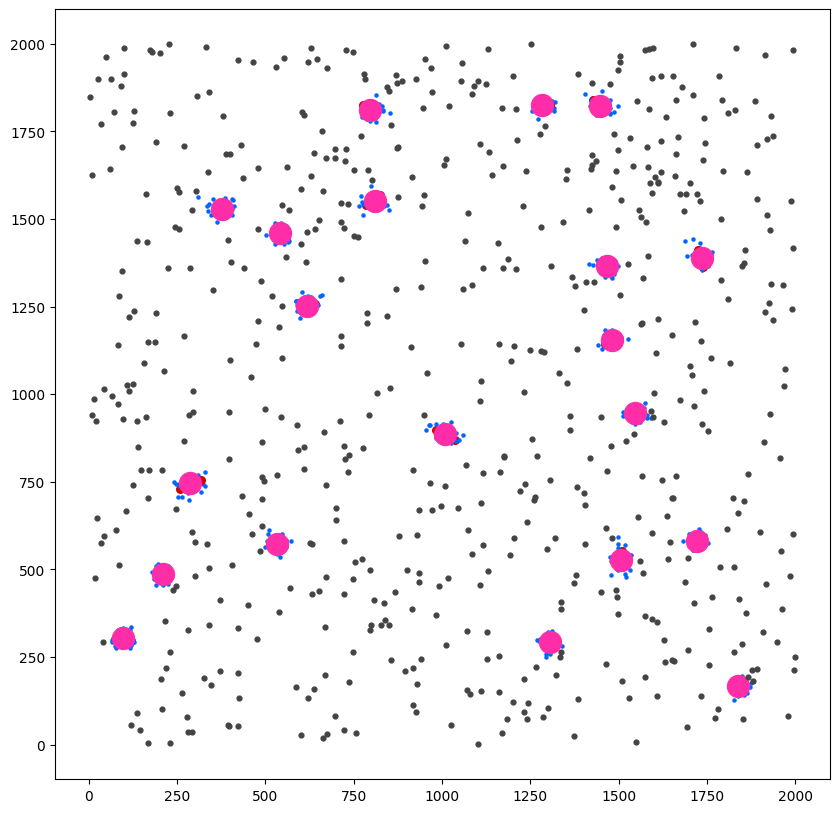

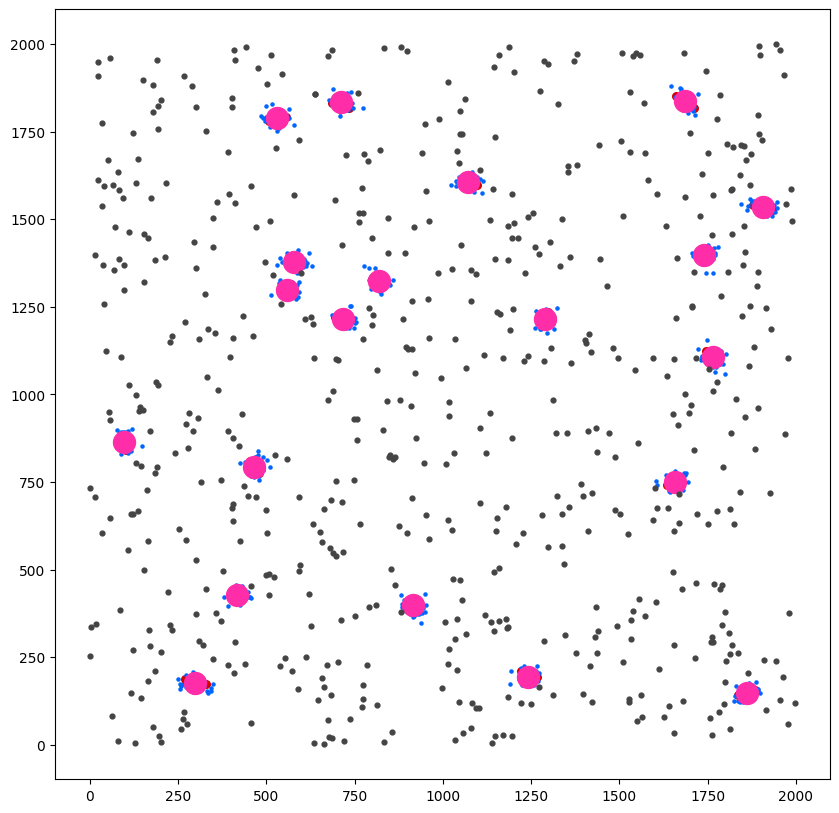

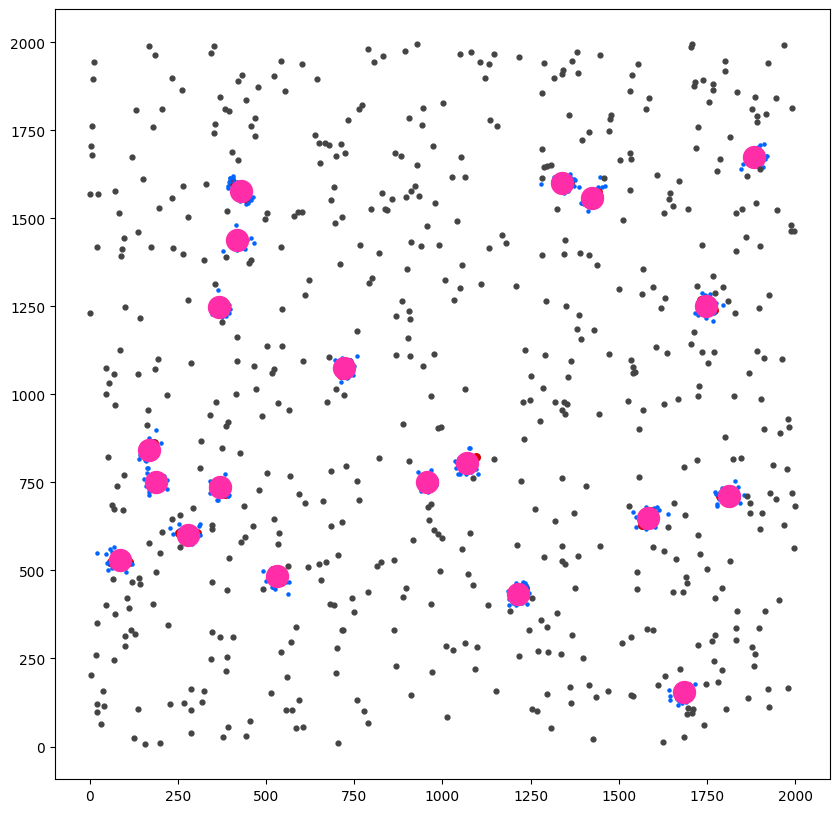

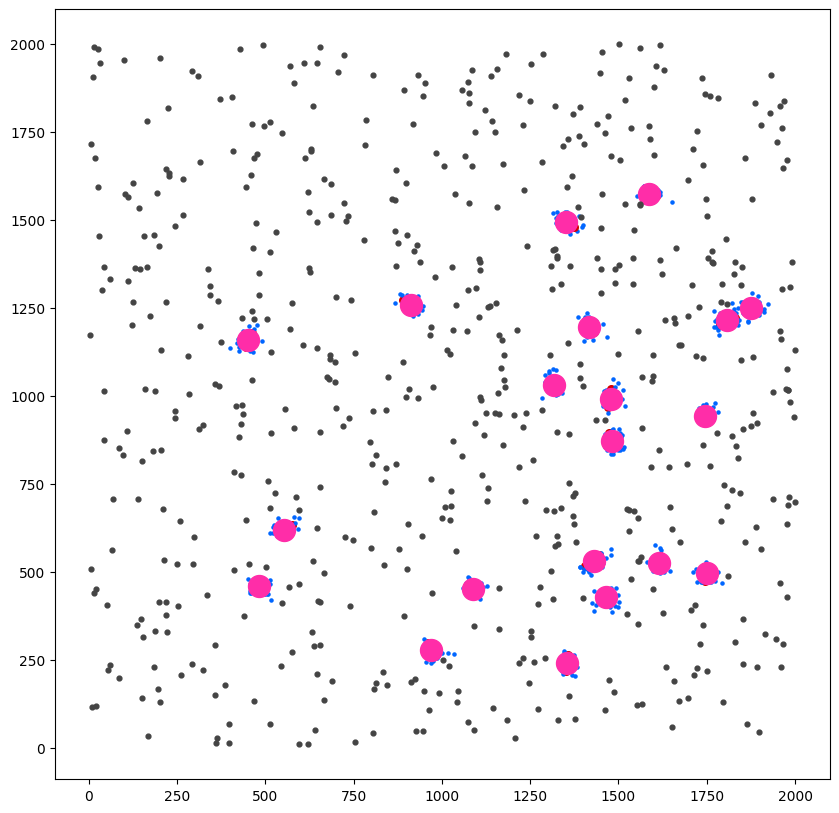

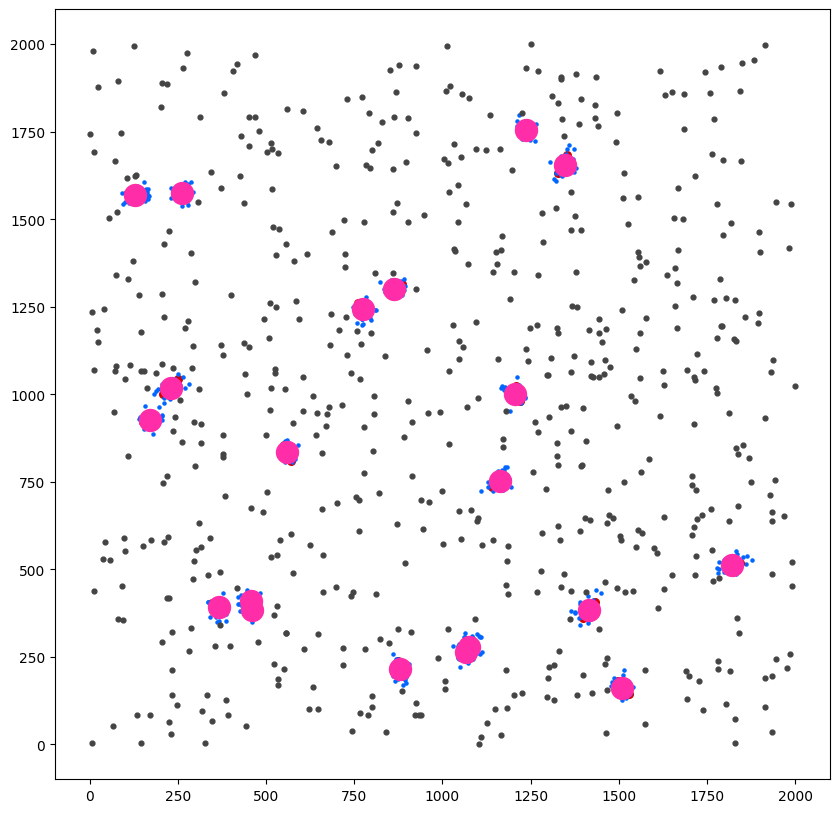

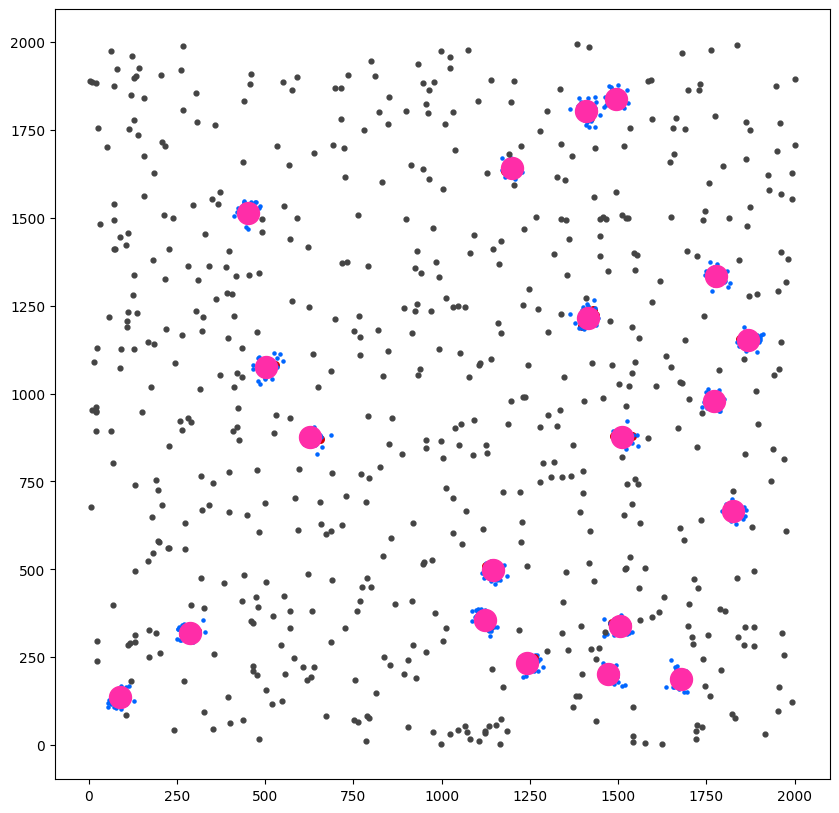

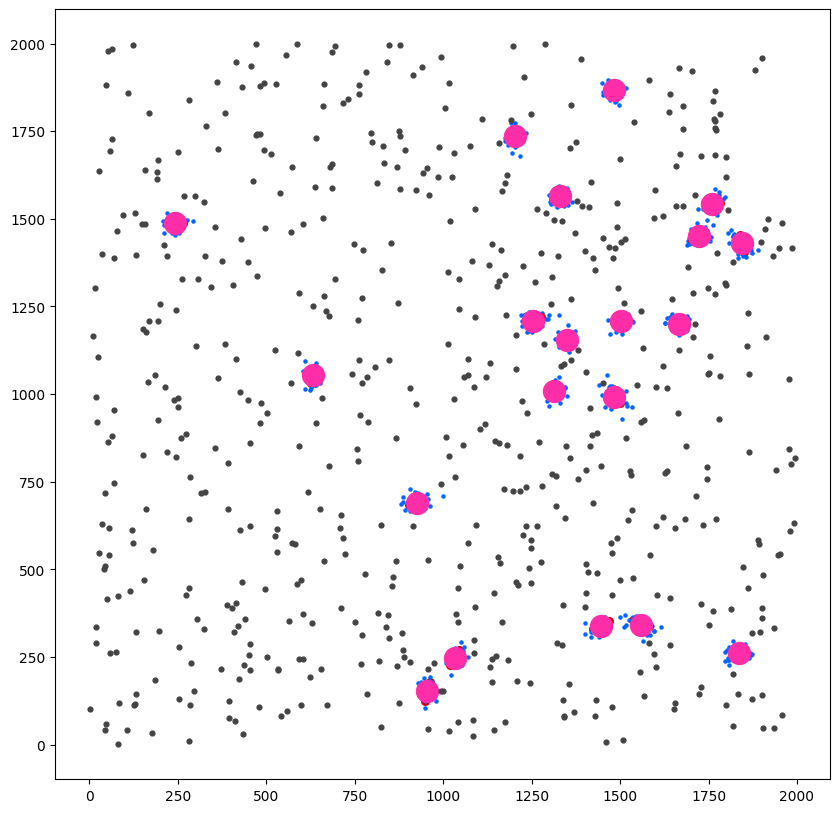

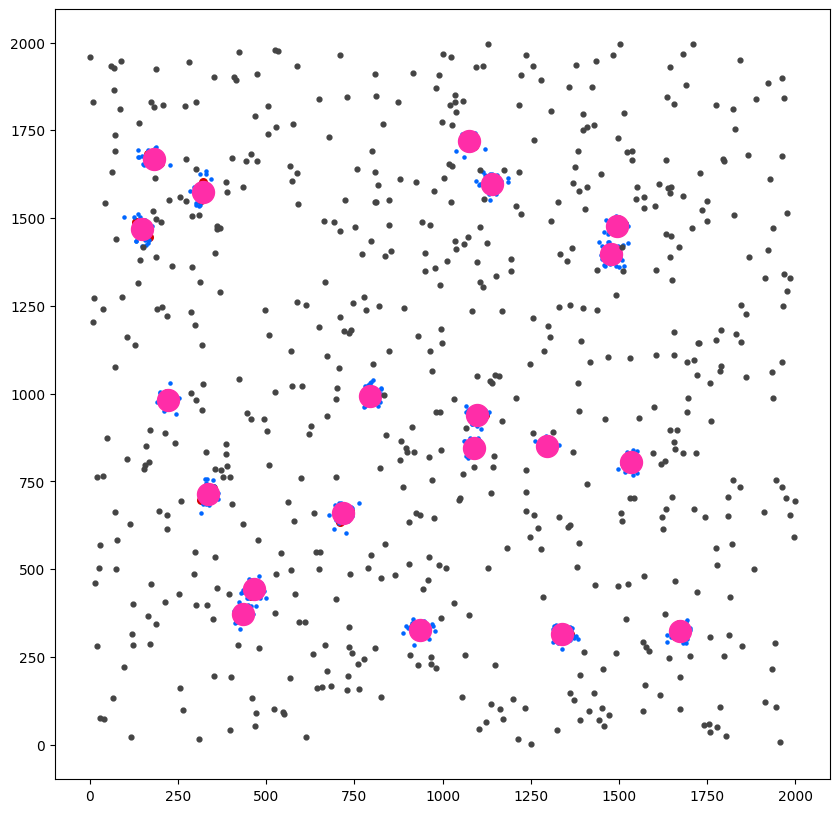

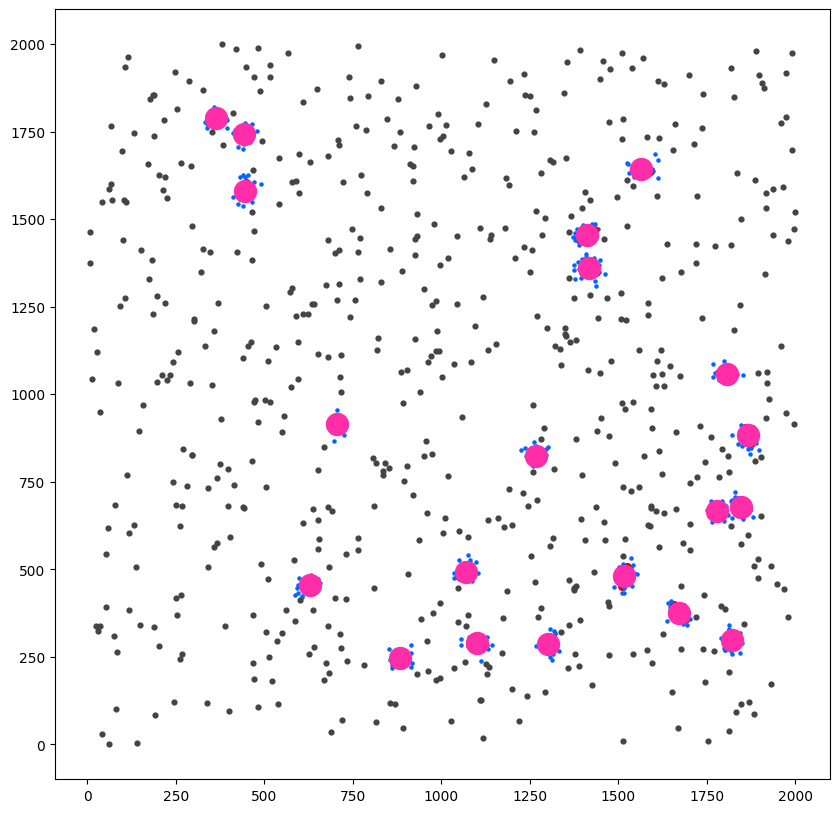

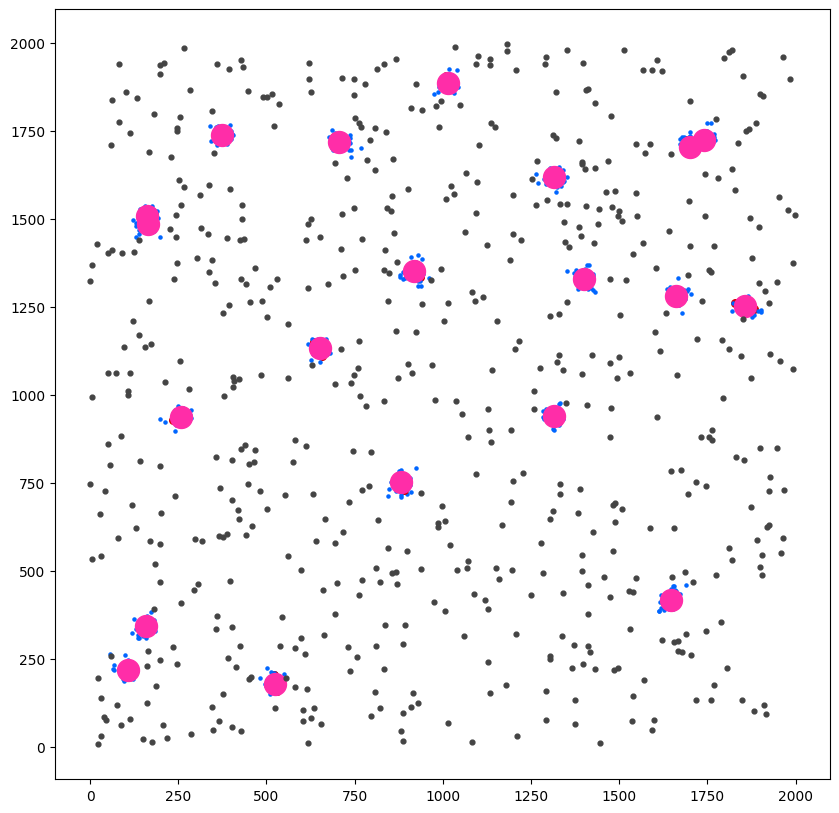

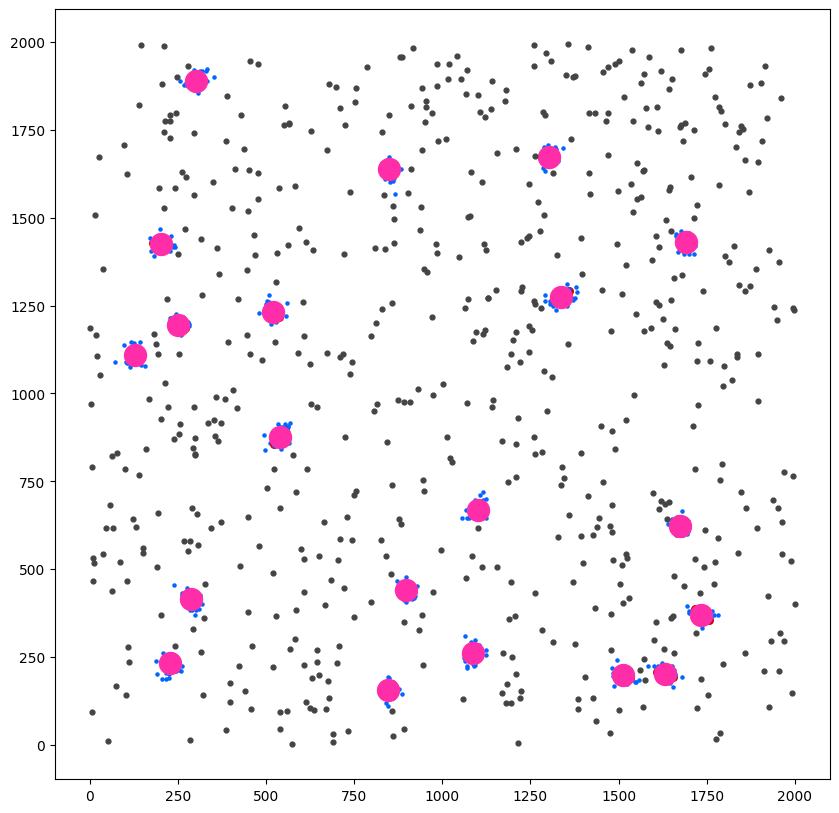

In [3]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

n_sims=50
disp = True

def generate_chain_cluster(start, n_proteins, link_min, link_max, overlap_min, max_tries=1000):
    proteins = [np.array(start, dtype=float)]

    for _ in range(1, n_proteins):
        placed = False

        for _ in range(max_tries):
            angle = np.random.uniform(0, 2 * np.pi)
            step = np.random.uniform(link_min, link_max)
            candidate = proteins[-1] + step * np.array([np.cos(angle), np.sin(angle)])

            if all(np.linalg.norm(candidate - p) >= overlap_min for p in proteins):
                proteins.append(candidate)
                placed = True
                break

        if not placed:
            break

    proteins = np.array(proteins)
    center = np.mean(proteins, axis=0)   # centroid of all proteins

    return proteins, center


def generate_noise_points(n_noise, H, protein_positions, min_dist, max_tries=100000):
    noise_points = []
    tries = 0

    while len(noise_points) < n_noise and tries < max_tries:
        candidate = np.random.uniform(0, H, size=2).astype(float)

        if all(np.linalg.norm(candidate - p) >= min_dist for p in protein_positions):
            noise_points.append(candidate)

        tries += 1

    if len(noise_points) < n_noise:
        raise ValueError("Could not place all noise points with the required separation.")

    return np.array(noise_points)

H = 2000
W = H
lim = 100

number_of_clusters = 20
# mean_number_of_proteins = 4
# stddev_number_of_proteins = 0
min_number_of_proteins = 5
max_number_of_proteins = 5
mean_number_of_proteins = (min_number_of_proteins + max_number_of_proteins) / 2
# stdev_cluster_radius = 50
link_min = 10      # minimum distance to previous protein
link_max = 20      # maximum distance to previous protein
overlap_min = link_min 
p_geo = 1/2 # 1 means that the mean number of localizations per protein is 1/p_geo
stdev_loc_prec = 15
min_locs_per_protein = 4 # minimum number of localizations per protein
noise_level = 1.0 * number_of_clusters * mean_number_of_proteins * ((1/p_geo) + min_locs_per_protein) # noise level as a function of the number of clusters, proteins and localizations

print(f'Noise: {noise_level}')

output_folder = "csv_generats"
os.makedirs(output_folder, exist_ok=True)

for run in range(n_sims):
    seed_coord = np.random.uniform(lim, H-lim, size=(number_of_clusters, 2))
    cluster_coord = np.zeros((number_of_clusters, 2))
    # noise_coord = np.random.uniform(0, H, size=(int(noise_level), 2))

    index_protein = 0
    index_cluster = 0

    data= []
    protein_positions_all=[]

    if disp:
        fig = plt.figure(figsize=(10, 10))


    for i in range(number_of_clusters):
        index_cluster = index_cluster + 1
        number_of_proteins = np.random.randint(min_number_of_proteins, max_number_of_proteins + 1)
        # number_of_proteins=np.random.normal(mean_number_of_proteins, stddev_number_of_proteins)
        # number_of_proteins = number_of_proteins if number_of_proteins > 0 else 1  

        protein_coord, cc  = generate_chain_cluster(
                                                seed_coord[i], 
                                                number_of_proteins, 
                                                link_min, 
                                                link_max, 
                                                overlap_min
                                                )
        
    
        cluster_coord[i, :]= cc

        for x,y in protein_coord:
            protein_positions_all.append([x, y])

            index_protein = index_protein + 1

            if disp:
                plt.scatter(x, y, color='#d40000', s=30)

            number_of_locs = np.random.geometric(p=p_geo) + min_locs_per_protein # add an offset to have at least min_locs_per_protein + 1 localizations per protein
            for k in range(number_of_locs):
                x_loc = x + np.random.normal(0, stdev_loc_prec)
                y_loc = y + np.random.normal(0, stdev_loc_prec)

                data.append([x_loc, y_loc, index_cluster])

                if disp:
                    plt.scatter(x_loc, y_loc, color='#0066ff', s=5)

    # noise_coord = np.random.uniform(0, H, size=(int(noise_level), 2))

    noise_coord = generate_noise_points(
        n_noise=int(noise_level),
        H=H,
        protein_positions=protein_positions_all,
        min_dist=2*stdev_loc_prec,
    )

    if disp:
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='#ff2da8', s=250, label='Cluster Centers')
        plt.scatter(noise_coord[:, 0], noise_coord[:, 1], color='#444444', s=12, label='Noise')

    for i in range(len(noise_coord)):
        x_noise = noise_coord[i, 0]
        y_noise = noise_coord[i, 1]
        data.append([x_noise, y_noise, 0])
    
    if disp and run==0:
        # --- 1) Només rosa (cluster centers) ---
        plt.figure(figsize=(15, 15))
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='#ff2da8', s=250, alpha=1.0, label='Cluster Centers', zorder=3)
        plt.title("Step 1: Cluster centers only", fontsize=25)
        plt.xlim(0, H); plt.ylim(0, H)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.savefig(f"step1_centers_{run+1}.png", dpi=300)
        plt.close()

        # --- 2) Rosa + vermell (proteïnes) ---
        plt.figure(figsize=(15, 15))
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='#ff2da8', s=250, alpha=1.0, label='Cluster Centers', zorder=3)
        proteins = np.array(protein_positions_all)
        plt.scatter(proteins[:, 0], proteins[:, 1], color='#d40000', s=90, alpha=1.0, label='Proteins', zorder=2)
        plt.title("Step 2: Centers + proteins", fontsize=25)
        plt.xlim(0, H); plt.ylim(0, H)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.savefig(f"step2_centers_proteins_{run+1}.png", dpi=300)
        plt.close()

        # --- 3) Rosa + vermell + blau (localitzacions) ---
        plt.figure(figsize=(15, 15))
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='#ff2da8', s=250, alpha=1.0, label='Cluster Centers', zorder=3)
        plt.scatter(proteins[:, 0], proteins[:, 1], color='#d40000', s=90, alpha=1.0, label='Proteins', zorder=2)

        locs = np.array([[x, y] for x, y, idx in data if idx != 0])
        plt.scatter(locs[:, 0], locs[:, 1], color='#0066ff', s=30, alpha=1.0, label='Localizations', zorder=1)

        plt.title("Step 3: Centers + proteins + localizations", fontsize=25)
        plt.xlim(0, H); plt.ylim(0, H)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.savefig(f"step3_centers_proteins_locs_{run+1}.png", dpi=300)
        plt.close()

        # --- 4) Rosa + vermell + blau + gris (soroll) ---
        plt.figure(figsize=(15, 15))
        plt.scatter(cluster_coord[:, 0], cluster_coord[:, 1], color='#ff2da8', s=250, alpha=1.0, label='Cluster Centers', zorder=3)
        plt.scatter(proteins[:, 0], proteins[:, 1], color='#d40000', s=90, alpha=1.0, label='Proteins', zorder=2)
        plt.scatter(locs[:, 0], locs[:, 1], color='#0066ff', s=30, alpha=1.0, label='Localizations', zorder=1)
        plt.scatter(noise_coord[:, 0], noise_coord[:, 1], color='#444444', s=12, alpha=1.0, label='Noise', zorder=0)

        plt.title("Step 4: Full dataset (centers + proteins + localizations + noise)", fontsize=25)
        plt.xlim(0, H); plt.ylim(0, H)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.savefig(f"step4_full_{run+1}.png", dpi=300)
        plt.close()

    df = pd.DataFrame(data, columns=["x", "y", "index"])
    filename = f"simulated_clusters_{run+1}.csv"
    output_path = os.path.join(output_folder, filename)
    df.to_csv(output_path, index=False)

    print(f"CSV guardado en: {output_path}")